In [1]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style for matplotlib
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [2]:
# Load the Dataset
# Load clinical data
clinical_train = pd.read_csv('raw_data/X_train/clinical_train.csv')
clinical_test = pd.read_csv('raw_data/X_test/clinical_test.csv')

# Load molecular data
molecular_train = pd.read_csv('raw_data/X_train/molecular_train.csv')
molecular_test = pd.read_csv('raw_data/X_test/molecular_test.csv')

# Load target
target_train = pd.read_csv('raw_data/target_train.csv')

print("Clinical train shape:", clinical_train.shape)
print("Molecular train shape:", molecular_train.shape)
print("Target train shape:", target_train.shape)

Clinical train shape: (3323, 9)
Molecular train shape: (10935, 11)
Target train shape: (3323, 3)


In [3]:
# Data Overview and Summary Statistics
print("=== CLINICAL DATA ===")
print("Shape:", clinical_train.shape)
print("\nData Types:")
print(clinical_train.dtypes.value_counts())
print("\nFirst 5 rows:")
display(clinical_train.head())
print("\nSummary Statistics:")
display(clinical_train.describe())

print("\n=== MOLECULAR DATA ===")
print("Shape:", molecular_train.shape)
print("\nData Types:")
print(molecular_train.dtypes.value_counts())
print("\nFirst 5 rows:")
display(molecular_train.head())
print("\nSummary Statistics:")
display(molecular_train.describe())

print("\n=== TARGET DATA ===")
print("Shape:", target_train.shape)
print("\nData Types:")
print(target_train.dtypes)
print("\nFirst 5 rows:")
display(target_train.head())
print("\nSummary Statistics:")
display(target_train.describe())

=== CLINICAL DATA ===
Shape: (3323, 9)

Data Types:
float64    6
object     3
Name: count, dtype: int64

First 5 rows:


,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]"
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx"
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]"
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]"
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]"



Summary Statistics:


,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT
count,3214.000000,3051.000000,3130.000000,2722.000000,3213.000000,3199.000000
mean,5.982545,6.535164,3.264735,0.955868,9.893549,167.048900
std,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031
min,0.000000,0.200000,0.000000,0.000000,4.000000,2.000000
25%,1.000000,2.700000,1.000000,0.150000,8.500000,65.500000
50%,3.000000,4.100000,2.000000,0.370000,9.700000,123.000000
75%,8.000000,6.655000,3.690000,0.783000,11.200000,229.500000
max,91.000000,154.400000,109.620000,44.200000,16.600000,1451.000000



=== MOLECULAR DATA ===
Shape: (10935, 11)

Data Types:
object     7
float64    4
Name: count, dtype: int64

First 5 rows:


...

,START,END,VAF,DEPTH
count,1.082100e+04,1.082100e+04,10846.000000,10821.000000
mean,8.078326e+07,8.078326e+07,0.305087,1051.229554
std,5.642656e+07,5.642656e+07,0.211524,552.861902
min,3.948990e+05,3.948990e+05,0.020000,16.000000
25%,3.102244e+07,3.102244e+07,0.102625,660.000000
50%,7.473296e+07,7.473296e+07,0.321250,975.000000
75%,1.152587e+08,1.152587e+08,0.442000,1353.000000
max,2.262521e+08,2.262521e+08,0.999000,7156.000000



=== TARGET DATA ===
Shape: (3323, 3)

Data Types:
ID            object
OS_YEARS     float64
OS_STATUS    float64
dtype: object

First 5 rows:


,ID,OS_YEARS,OS_STATUS
0,P132697,1.115068,1.0
1,P132698,4.928767,0.0
2,P116889,2.043836,0.0
3,P132699,2.476712,1.0
4,P132700,3.145205,0.0



Summary Statistics:


,OS_YEARS,OS_STATUS
count,3173.000000,3173.000000
mean,2.480713,0.504255
std,2.588259,0.500061
min,0.000000,0.000000
25%,0.652055,0.000000
50%,1.652055,1.000000
75%,3.572603,1.000000
max,22.043836,1.000000


=== MISSING VALUES ANALYSIS ===
Clinical data missing values:
BM_BLAST: 109 (3.28%)
WBC: 272 (8.19%)
ANC: 193 (5.81%)
MONOCYTES: 601 (18.09%)
HB: 110 (3.31%)
PLT: 124 (3.73%)
CYTOGENETICS: 387 (11.65%)

Molecular data missing values:
CHR: 114 (1.04%)
START: 114 (1.04%)
END: 114 (1.04%)
REF: 114 (1.04%)
ALT: 114 (1.04%)
PROTEIN_CHANGE: 12 (0.11%)
VAF: 89 (0.81%)
DEPTH: 114 (1.04%)

Target missing values: 300


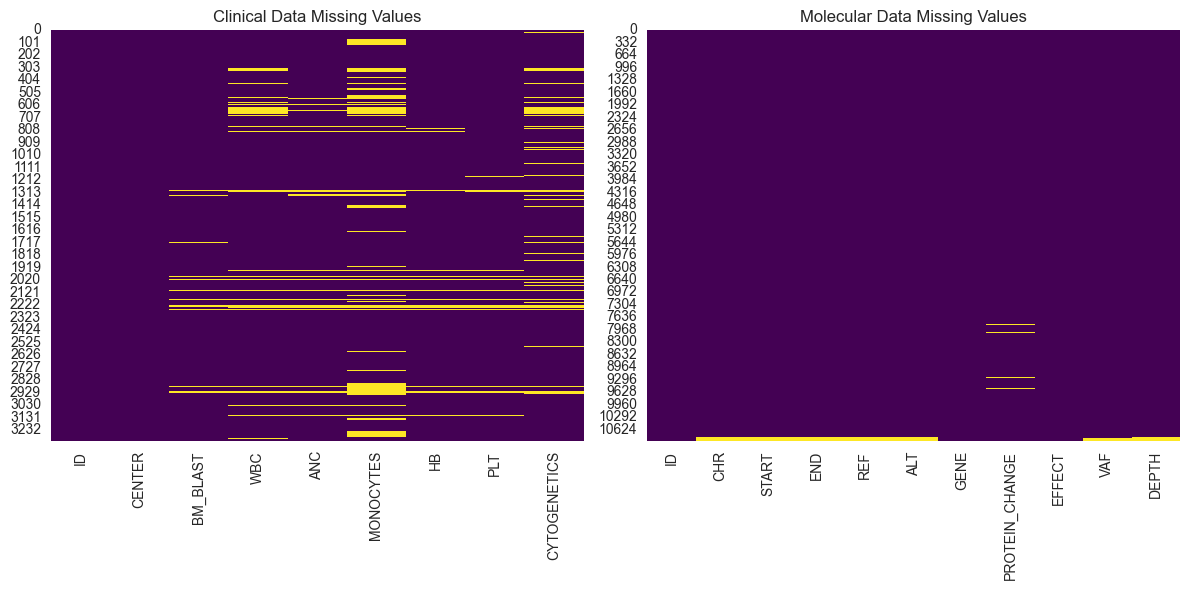

In [4]:
# Handle Missing Values
print("=== MISSING VALUES ANALYSIS ===")

# Clinical data missing values
clinical_missing = clinical_train.isnull().sum()
clinical_missing_pct = (clinical_missing / len(clinical_train)) * 100

print("Clinical data missing values:")
for col, count in clinical_missing[clinical_missing > 0].items():
    print(f"{col}: {count} ({clinical_missing_pct[col]:.2f}%)")

# Molecular data missing values
molecular_missing = molecular_train.isnull().sum()
molecular_missing_pct = (molecular_missing / len(molecular_train)) * 100

print("\nMolecular data missing values:")
for col, count in molecular_missing[molecular_missing > 0].items():
    print(f"{col}: {count} ({molecular_missing_pct[col]:.2f}%)")

# Target missing values
target_missing = target_train.isnull().sum()
print(f"\nTarget missing values: {target_missing.sum()}")

# Visualize missing values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.heatmap(clinical_train.isnull(), cbar=False, cmap='viridis')
plt.title('Clinical Data Missing Values')
plt.subplot(1, 2, 2)
sns.heatmap(molecular_train.isnull(), cbar=False, cmap='viridis')
plt.title('Molecular Data Missing Values')
plt.tight_layout()
plt.show()

In [5]:
# Data Visualization - Distributions
# Select clinical features excluding WBC due to multicollinearity
clinical_numeric = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']

fig = make_subplots(rows=3, cols=2, subplot_titles=clinical_numeric + ['Survival Time'])

# Histograms for clinical features
for i, col in enumerate(clinical_numeric):
    row = (i // 2) + 1
    col_pos = (i % 2) + 1
    fig.add_trace(go.Histogram(x=clinical_train[col].dropna(), name=col), row=row, col=col_pos)

# Survival time distribution
fig.add_trace(go.Histogram(x=target_train['OS_YEARS'].dropna(), name='Survival Time'), row=3, col=2)

fig.update_layout(height=800, title_text="Distributions of Clinical Features and Survival Time")
fig.show()



## Hypothèse sur les variables exclues

À partir de cette section de l'analyse exploratoire, nous excluons les variables **CENTER**, **CYTOGENETICS** et **WBC** des variables cliniques considérées.

**Hypothèse :** Nous négligeons l'impact prédictif de CENTER, CYTOGENETICS et WBC sur la survie des patients, en nous concentrant uniquement sur les variables numériques cliniques restantes (BM_BLAST, ANC, MONOCYTES, HB, PLT) pour simplifier l'analyse et nous focaliser sur les marqueurs biologiques quantitatifs non redondants.

**Raison pour exclure WBC :** WBC présente une forte multicolinéarité avec ANC (corrélation = 0.847) et MONOCYTES (corrélation = 0.748), car ANC et MONOCYTES sont des composants de WBC. Retirer WBC évite les problèmes de stabilité dans les modèles prédictifs tout en conservant l'information plus spécifique apportée par ANC et MONOCYTES.

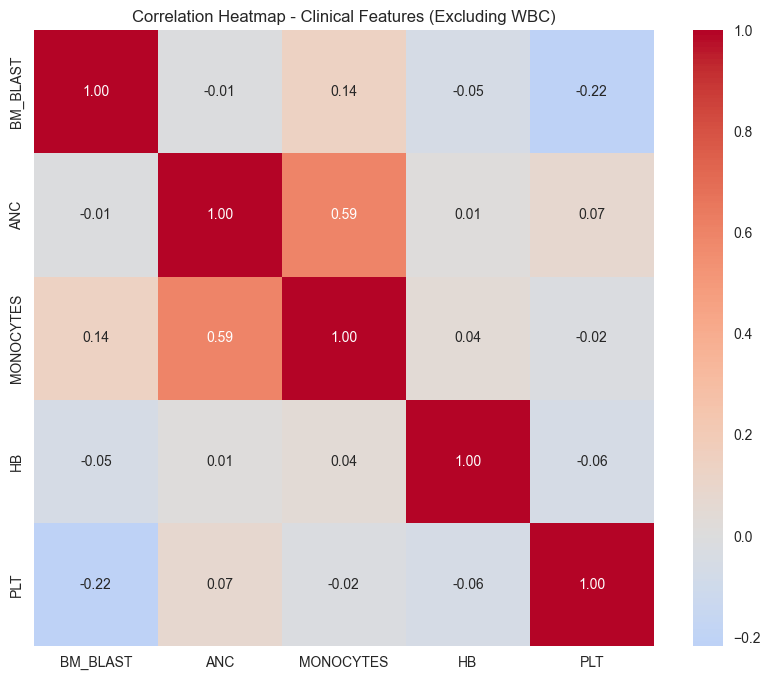

In [6]:
# Data Visualization - Relationships
# Correlation heatmap for clinical data (excluding WBC)
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']
clinical_corr = clinical_train[clinical_features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(clinical_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Clinical Features (Excluding WBC)')
plt.show()



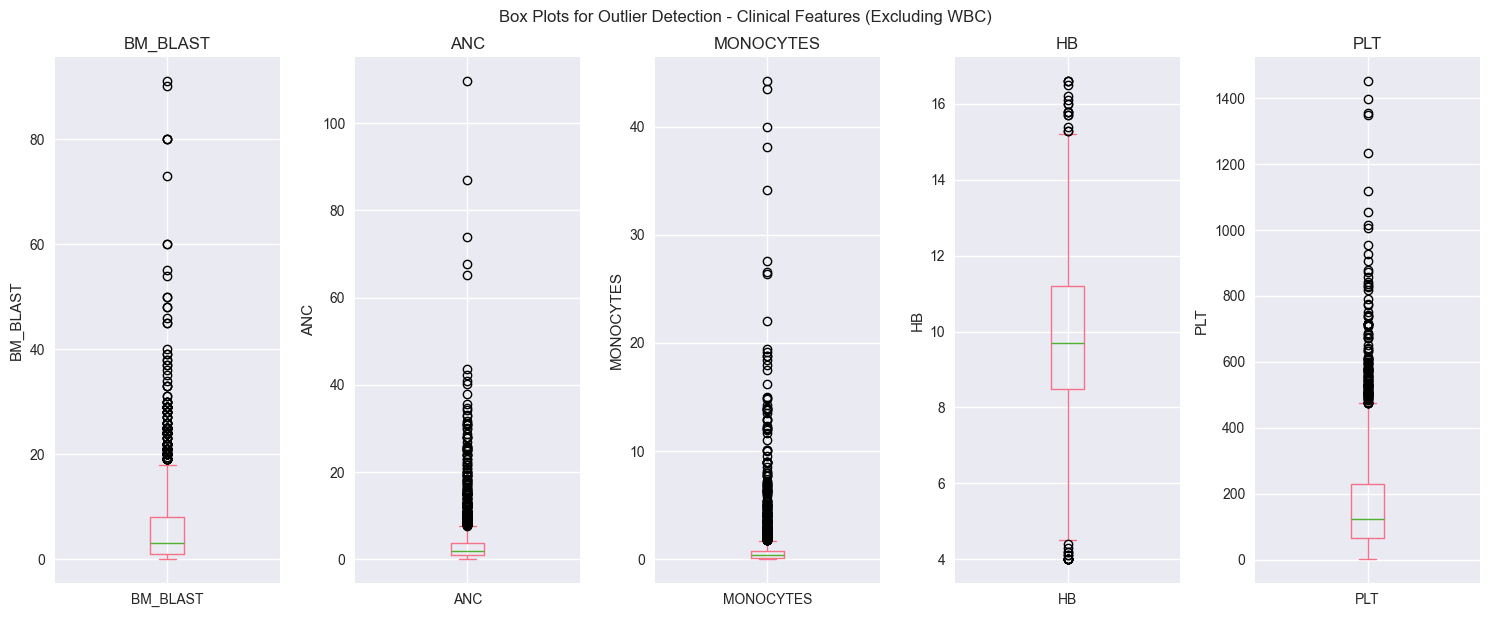

In [7]:
# Outlier Detection
# Using box plots to identify outliers in clinical data (excluding WBC)
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']

# Create subplots for each feature
fig, axes = plt.subplots(1, len(clinical_features), figsize=(15, 6))
for i, col in enumerate(clinical_features):
    clinical_train[col].dropna().plot(kind='box', ax=axes[i], title=col)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Box Plots for Outlier Detection - Clinical Features (Excluding WBC)', y=1.02)
plt.show()



Original vs Log-transformed Distributions:


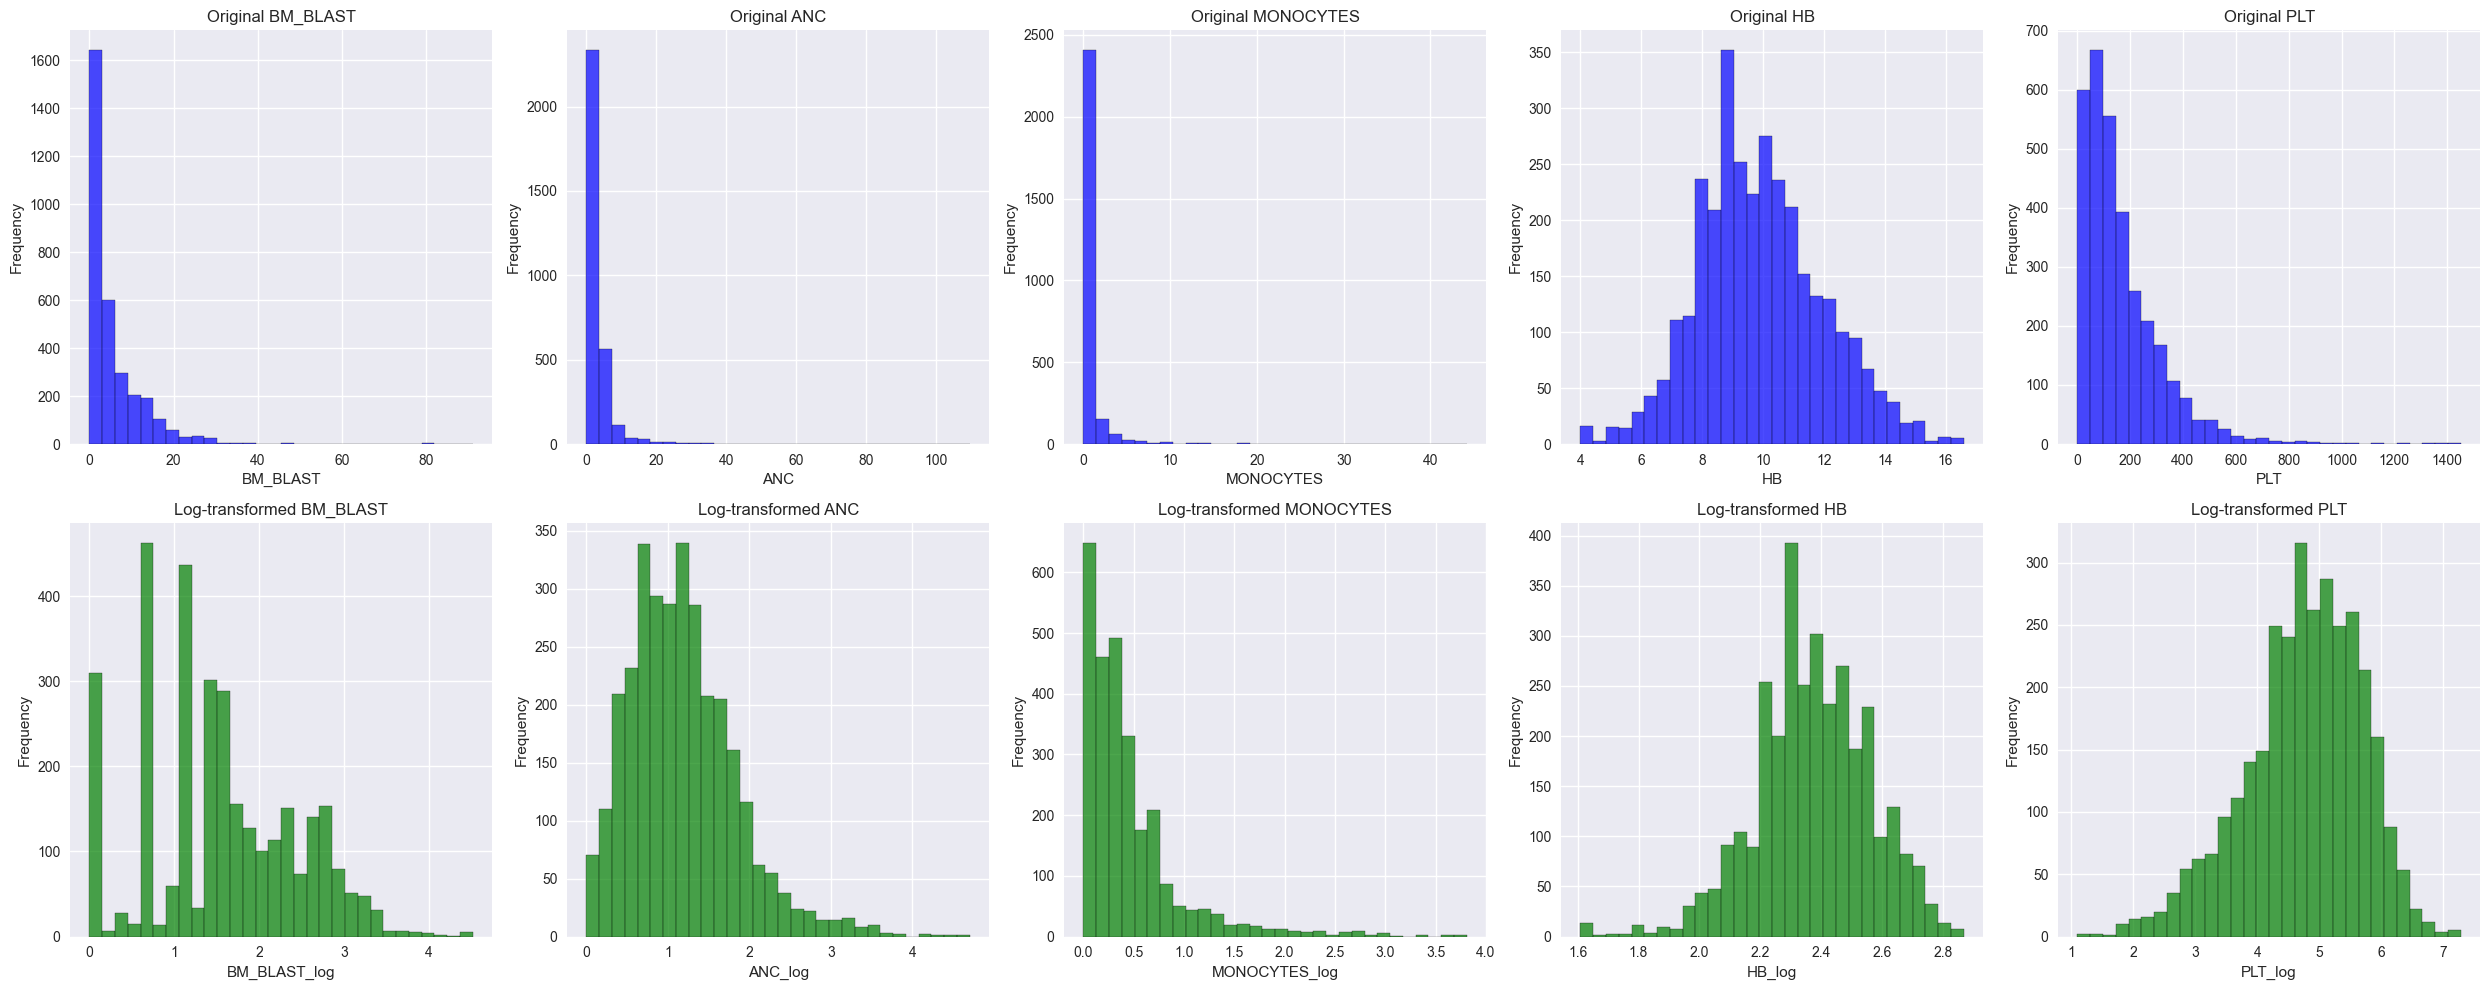


Box Plots After Log Transformation:


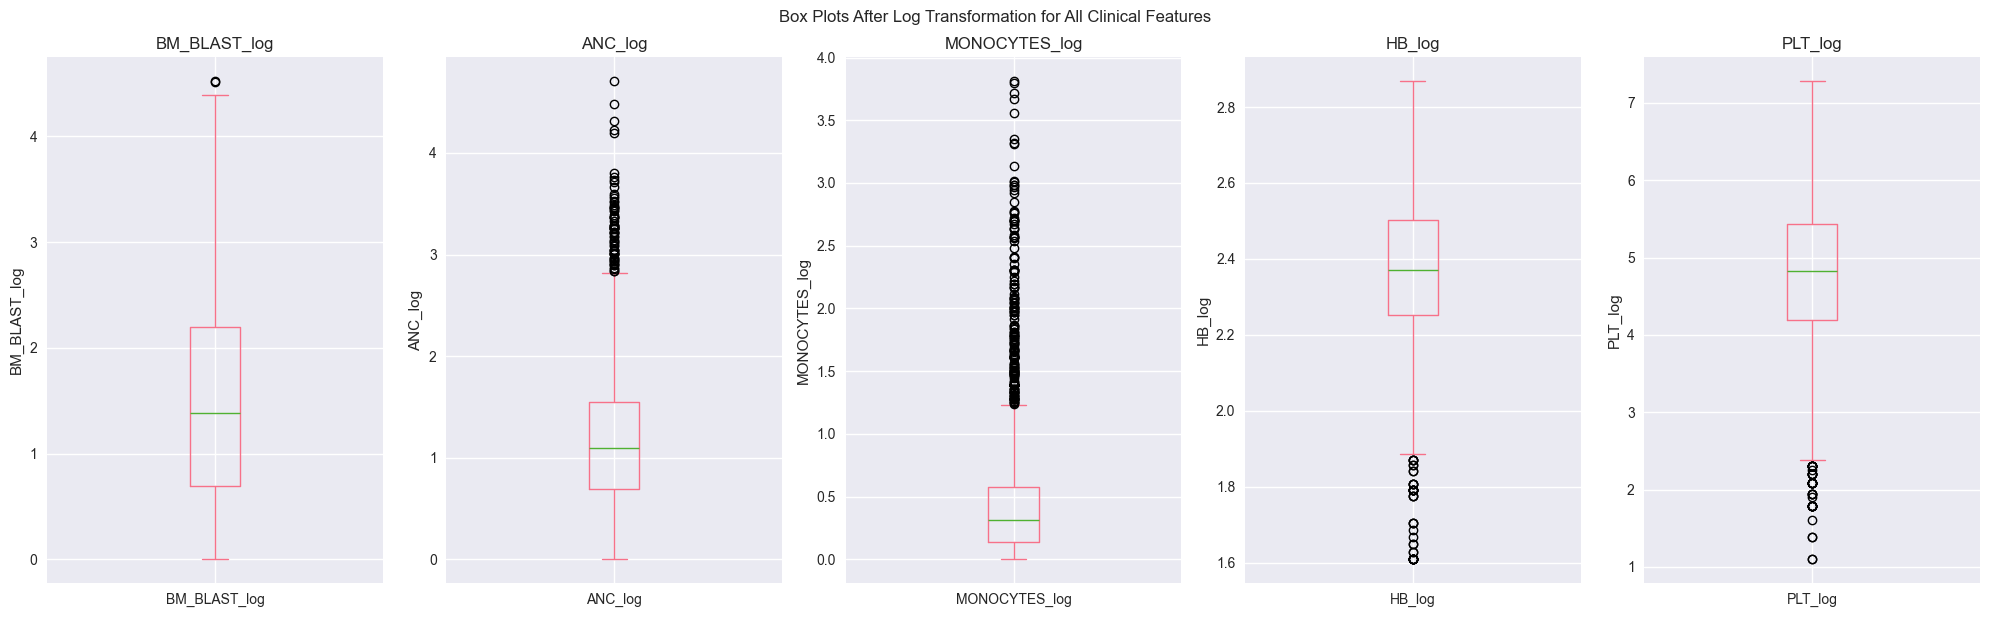

In [8]:
# Data Transformation - Log Transformation for All Clinical Variables
# Apply log(x + 1) transformation to all clinical features to reduce skewness
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']

# Create transformed dataframe
clinical_transformed = clinical_train.copy()
for col in clinical_features:
    clinical_transformed[f'{col}_log'] = np.log1p(clinical_train[col])

print("Original vs Log-transformed Distributions:")
fig, axes = plt.subplots(2, len(clinical_features), figsize=(25, 10))

for i, col in enumerate(clinical_features):
    # Original
    axes[0, i].hist(clinical_train[col].dropna(), bins=30, alpha=0.7, color='blue', edgecolor='black')
    axes[0, i].set_title(f'Original {col}')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')
    
    # Transformed
    axes[1, i].hist(clinical_transformed[f'{col}_log'].dropna(), bins=30, alpha=0.7, color='green', edgecolor='black')
    axes[1, i].set_title(f'Log-transformed {col}')
    axes[1, i].set_xlabel(f'{col}_log')
    axes[1, i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plots after transformation
print("\nBox Plots After Log Transformation:")
fig, axes = plt.subplots(1, len(clinical_features), figsize=(20, 6))
for i, col in enumerate(clinical_features):
    clinical_transformed[f'{col}_log'].dropna().plot(kind='box', ax=axes[i], title=f'{col}_log')
    axes[i].set_ylabel(f'{col}_log')

plt.tight_layout()
plt.suptitle('Box Plots After Log Transformation for All Clinical Features', y=1.02)
plt.show()

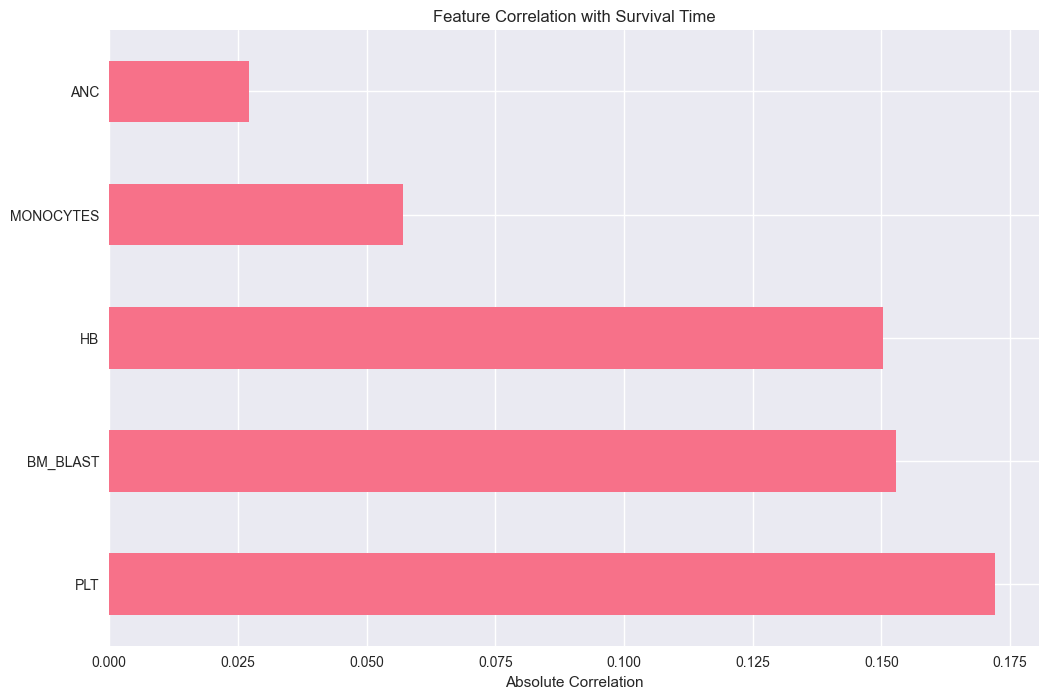

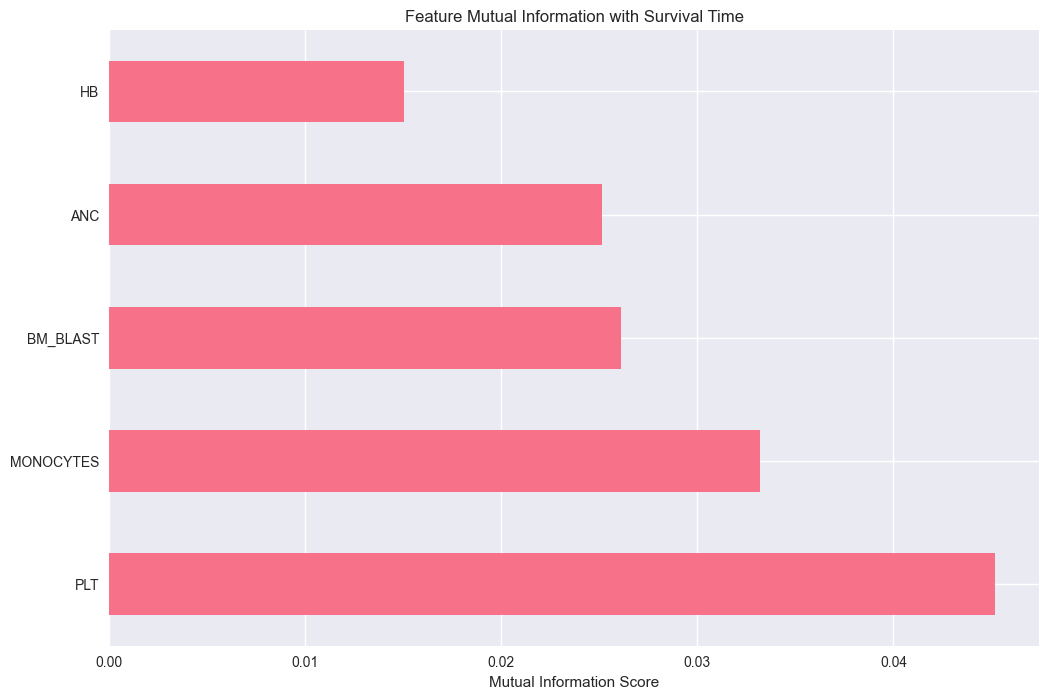

In [9]:
# Feature Importance Analysis
# Correlation with survival time (excluding WBC)
clinical_features = ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']
survival_corr = pd.concat([clinical_train[clinical_features], target_train['OS_YEARS']], axis=1).corr()['OS_YEARS'].drop('OS_YEARS').abs().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
survival_corr.plot(kind='barh')
plt.title('Feature Correlation with Survival Time')
plt.xlabel('Absolute Correlation')
plt.show()

# Mutual information for feature importance (if sklearn available)

from sklearn.feature_selection import mutual_info_regression

# Prepare data
clinical_clean = clinical_train[clinical_features].dropna()
target_clean = target_train.loc[clinical_clean.index, 'OS_YEARS'].dropna()
clinical_clean = clinical_clean.loc[target_clean.index]

mi_scores = mutual_info_regression(clinical_clean, target_clean)
mi_scores = pd.Series(mi_scores, index=clinical_clean.columns).sort_values(ascending=False)

plt.figure(figsize=(12, 8))
mi_scores.plot(kind='barh')
plt.title('Feature Mutual Information with Survival Time')
plt.xlabel('Mutual Information Score')
plt.show()
    



In [10]:
# Molecular Data Aggregation - Filtered to 8 pertinent features
# Aggregate molecular data by patient ID with key numerical features
molecular_agg = molecular_train.groupby('ID').agg({
    'CHR': 'count',        # Total variants
    'VAF': ['mean', 'max'], # Average and max variant allele frequency
    'DEPTH': 'mean'        # Average sequencing depth
}).reset_index()

# Flatten column names
molecular_agg.columns = ['ID', 'total_variants', 'mean_VAF', 'max_VAF', 'mean_DEPTH']

# Count variants by pertinent effect type (functional impact)
pertinent_effects = ['non_synonymous_codon', 'frameshift_variant', 'splice_site_variant', 'stop_gained']
effect_counts = molecular_train[molecular_train['EFFECT'].isin(pertinent_effects)].pivot_table(
    index='ID', columns='EFFECT', aggfunc='size', fill_value=0
)
effect_counts.columns = [f'count_{col}' for col in effect_counts.columns]

# Merge aggregations
molecular_agg = molecular_agg.merge(effect_counts, left_on='ID', right_index=True, how='left').fillna(0)

# Ensure all pertinent effects are present (fill missing with 0)
for effect in pertinent_effects:
    col_name = f'count_{effect}'
    if col_name not in molecular_agg.columns:
        molecular_agg[col_name] = 0

# Select final 8 features
final_features = ['ID', 'total_variants', 'mean_VAF', 'max_VAF', 'mean_DEPTH',
                  'count_non_synonymous_codon', 'count_frameshift_variant', 
                  'count_splice_site_variant', 'count_stop_gained']
molecular_agg = molecular_agg[final_features]

print("=== MOLECULAR DATA AGGREGATION (FILTERED) ===")
print("Aggregated molecular features shape:", molecular_agg.shape)
print("Aggregated features (8 pertinent):", list(molecular_agg.columns[1:]))
print("\nSummary statistics:")
print(molecular_agg.iloc[:, 1:].describe())

# Apply same aggregation to test data
molecular_agg_test = molecular_test.groupby('ID').agg({
    'CHR': 'count',
    'VAF': ['mean', 'max'],
    'DEPTH': 'mean'
}).reset_index()
molecular_agg_test.columns = ['ID', 'total_variants', 'mean_VAF', 'max_VAF', 'mean_DEPTH']

effect_counts_test = molecular_test[molecular_test['EFFECT'].isin(pertinent_effects)].pivot_table(
    index='ID', columns='EFFECT', aggfunc='size', fill_value=0
)
effect_counts_test.columns = [f'count_{col}' for col in effect_counts_test.columns]
molecular_agg_test = molecular_agg_test.merge(effect_counts_test, left_on='ID', right_index=True, how='left').fillna(0)

# Ensure all pertinent effects are present
for effect in pertinent_effects:
    col_name = f'count_{effect}'
    if col_name not in molecular_agg_test.columns:
        molecular_agg_test[col_name] = 0

# Select final 8 features
molecular_agg_test = molecular_agg_test[final_features]

print("Aggregated molecular data ready for modeling.")

=== MOLECULAR DATA AGGREGATION (FILTERED) ===
Aggregated molecular features shape: (3026, 9)
Aggregated features (8 pertinent): ['total_variants', 'mean_VAF', 'max_VAF', 'mean_DEPTH', 'count_non_synonymous_codon', 'count_frameshift_variant', 'count_splice_site_variant', 'count_stop_gained']

Summary statistics:
       total_variants     mean_VAF      max_VAF   mean_DEPTH  \
count     3026.000000  3026.000000  3026.000000  3026.000000   
mean         3.576008     0.306837     0.445187  1067.796006   
std          2.210345     0.159831     0.229293   456.139314   
min          0.000000     0.000000     0.000000     0.000000   
25%          2.000000     0.192339     0.305150   751.500000   
50%          3.000000     0.297000     0.442000  1001.000000   
75%          5.000000     0.410700     0.509000  1323.166667   
max         17.000000     0.989000     0.999000  4292.000000   

       count_non_synonymous_codon  count_frameshift_variant  \
count                 3026.000000              

In [11]:
# Feature Engineering - Cytogénétique & Gènes
# ============================================

def extract_cytogenetics_features(df):
    """Features cytogénétiques depuis CYTOGENETICS"""
    cyto = df['CYTOGENETICS'].fillna('MISSING')
    features = pd.DataFrame({'ID': df['ID']})
    
    # Patterns cytogénétiques
    patterns = {
        'is_normal_karyotype': r'^46,(xx|xy)(\[\d+\])?$',
        'has_monosomy_7': '-7',
        'has_del5q': r'del.5',
        'has_del7q': r'del.7',
        'has_trisomy_8': r'\+8',
        'has_del20q': r'del.20'
    }
    
    for name, pattern in patterns.items():
        if name == 'is_normal_karyotype':
            features[name] = cyto.str.match(pattern, case=False).astype(int)
        else:
            features[name] = cyto.str.contains(pattern, case=False, na=False).astype(int)
    
    features['is_complex_karyotype'] = cyto.str.count('/').ge(2).astype(int)
    features['cyto_missing'] = df['CYTOGENETICS'].isna().astype(int)
    
    # Score de risque (IPSS-R simplifié: 0=bon, 4=très mauvais)
    features['cyto_risk_score'] = 1
    features.loc[features['is_normal_karyotype'] == 1, 'cyto_risk_score'] = 0
    features.loc[features['has_del7q'] == 1, 'cyto_risk_score'] = 2
    features.loc[features['has_monosomy_7'] == 1, 'cyto_risk_score'] = 3
    features.loc[features['is_complex_karyotype'] == 1, 'cyto_risk_score'] = 4
    
    return features

def extract_gene_features(molecular_df):
    """Features génétiques depuis données moléculaires"""
    # Groupes de gènes pronostiques
    gene_groups = {
        'high_risk': ['TP53', 'ASXL1', 'RUNX1', 'EZH2'],
        'splicing': ['SF3B1', 'SRSF2', 'U2AF1', 'ZRSR2'],
        'epigenetic': ['TET2', 'DNMT3A', 'IDH1', 'IDH2', 'EZH2', 'ASXL1'],
        'signaling': ['NRAS', 'KRAS', 'FLT3', 'CBL', 'NF1']
    }
    key_genes = ['TP53', 'ASXL1', 'RUNX1', 'EZH2', 'SF3B1', 'SRSF2', 'TET2', 'DNMT3A']
    
    genes_by_patient = molecular_df.groupby('ID')['GENE'].apply(set).reset_index()
    genes_by_patient.columns = ['ID', 'gene_set']
    
    features = pd.DataFrame({'ID': genes_by_patient['ID']})
    
    # Indicateurs binaires pour gènes clés
    for gene in key_genes:
        features[f'has_{gene}'] = genes_by_patient['gene_set'].apply(lambda x: int(gene in x))
    
    # Comptages par groupe fonctionnel
    for group_name, genes in gene_groups.items():
        features[f'n_{group_name}_genes'] = genes_by_patient['gene_set'].apply(
            lambda x: len(x.intersection(genes)))
    
    features['n_unique_genes'] = genes_by_patient['gene_set'].apply(len)
    
    return features

# Application train/test
cyto_features_train = extract_cytogenetics_features(clinical_train)
cyto_features_test = extract_cytogenetics_features(clinical_test)
gene_features_train = extract_gene_features(molecular_train)
gene_features_test = extract_gene_features(molecular_test)

print(f"✓ Features cytogénétiques: {len(cyto_features_train.columns)-1}")
print(f"✓ Features génétiques: {len(gene_features_train.columns)-1}")
print(f"✓ Total nouvelles features: {len(cyto_features_train.columns) + len(gene_features_train.columns) - 2}")

✓ Features cytogénétiques: 9
✓ Features génétiques: 13
✓ Total nouvelles features: 22


In [12]:
# Visualize distributions of all molecular features with improved readability
molecular_features = ['total_variants', 'mean_VAF', 'max_VAF', 'mean_DEPTH',
                      'count_non_synonymous_codon', 'count_frameshift_variant', 
                      'count_splice_site_variant', 'count_stop_gained']

# Custom titles for better readability
feature_titles = [
    'Total Variants<br><sub>Charge mutationnelle globale</sub>',
    'Mean VAF<br><sub>Fréquence allélique moyenne</sub>',
    'Max VAF<br><sub>Fréquence allélique maximale</sub>',
    'Mean Depth<br><sub>Profondeur séquençage moyenne</sub>',
    'Non-synonymous Codons<br><sub>Mutations changeant acides aminés</sub>',
    'Frameshift Variants<br><sub>Mutations graves (décalage)</sub>',
    'Splice Site Variants<br><sub>Mutations épissage (rares)</sub>',
    'Stop Gained<br><sub>Création de codon STOP</sub>'
]

fig = make_subplots(rows=2, cols=4, subplot_titles=feature_titles, 
                    specs=[[{'type': 'histogram'}, {'type': 'histogram'}, {'type': 'histogram'}, {'type': 'histogram'}],
                           [{'type': 'histogram'}, {'type': 'histogram'}, {'type': 'histogram'}, {'type': 'histogram'}]])

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

for i, (col, title, color) in enumerate(zip(molecular_features, feature_titles, colors)):
    row = (i // 4) + 1
    col_pos = (i % 4) + 1
    fig.add_trace(go.Histogram(x=molecular_agg[col].dropna(), name=col, nbinsx=30, 
                               marker_color=color, opacity=0.7), row=row, col=col_pos)
    fig.update_xaxes(title_text=col, title_font=dict(size=10), row=row, col=col_pos)
    fig.update_yaxes(title_text='Count', row=row, col=col_pos)

fig.update_layout(height=800, width=1400, title_text="Distributions of Molecular Features", 
                  showlegend=False, title_font_size=16, font=dict(size=11))
fig.show()

print("\n" + "="*80)
print("MOLECULAR FEATURES DISTRIBUTIONS SUMMARY")
print("="*80)
for col in molecular_features:
    print(f"\n{col.upper()}")
    print(f"  {'Mean':<15}: {molecular_agg[col].mean():.4f}")
    print(f"  {'Median':<15}: {molecular_agg[col].median():.4f}")
    print(f"  {'Min - Max':<15}: {molecular_agg[col].min():.4f} - {molecular_agg[col].max():.4f}")
    print(f"  {'Std Dev':<15}: {molecular_agg[col].std():.4f}")
    print(f"  {'Zeros':<15}: {(molecular_agg[col] == 0).sum()} ({(molecular_agg[col] == 0).sum() / len(molecular_agg) * 100:.1f}%)")
print("="*80)


MOLECULAR FEATURES DISTRIBUTIONS SUMMARY

TOTAL_VARIANTS
  Mean           : 3.5760
  Median         : 3.0000
  Min - Max      : 0.0000 - 17.0000
  Std Dev        : 2.2103
  Zeros          : 2 (0.1%)

MEAN_VAF
  Mean           : 0.3068
  Median         : 0.2970
  Min - Max      : 0.0000 - 0.9890
  Std Dev        : 0.1598
  Zeros          : 2 (0.1%)

MAX_VAF
  Mean           : 0.4452
  Median         : 0.4420
  Min - Max      : 0.0000 - 0.9990
  Std Dev        : 0.2293
  Zeros          : 2 (0.1%)

MEAN_DEPTH
  Mean           : 1067.7960
  Median         : 1001.0000
  Min - Max      : 0.0000 - 4292.0000
  Std Dev        : 456.1393
  Zeros          : 2 (0.1%)

COUNT_NON_SYNONYMOUS_CODON
  Mean           : 1.8080
  Median         : 2.0000
  Min - Max      : 0.0000 - 8.0000
  Std Dev        : 1.2768
  Zeros          : 350 (11.6%)

COUNT_FRAMESHIFT_VARIANT
  Mean           : 0.9508
  Median         : 1.0000
  Min - Max      : 0.0000 - 9.0000
  Std Dev        : 1.1056
  Zeros          : 1316 

Original vs Log-transformed Distributions (6 variables transformed, 2 kept original):


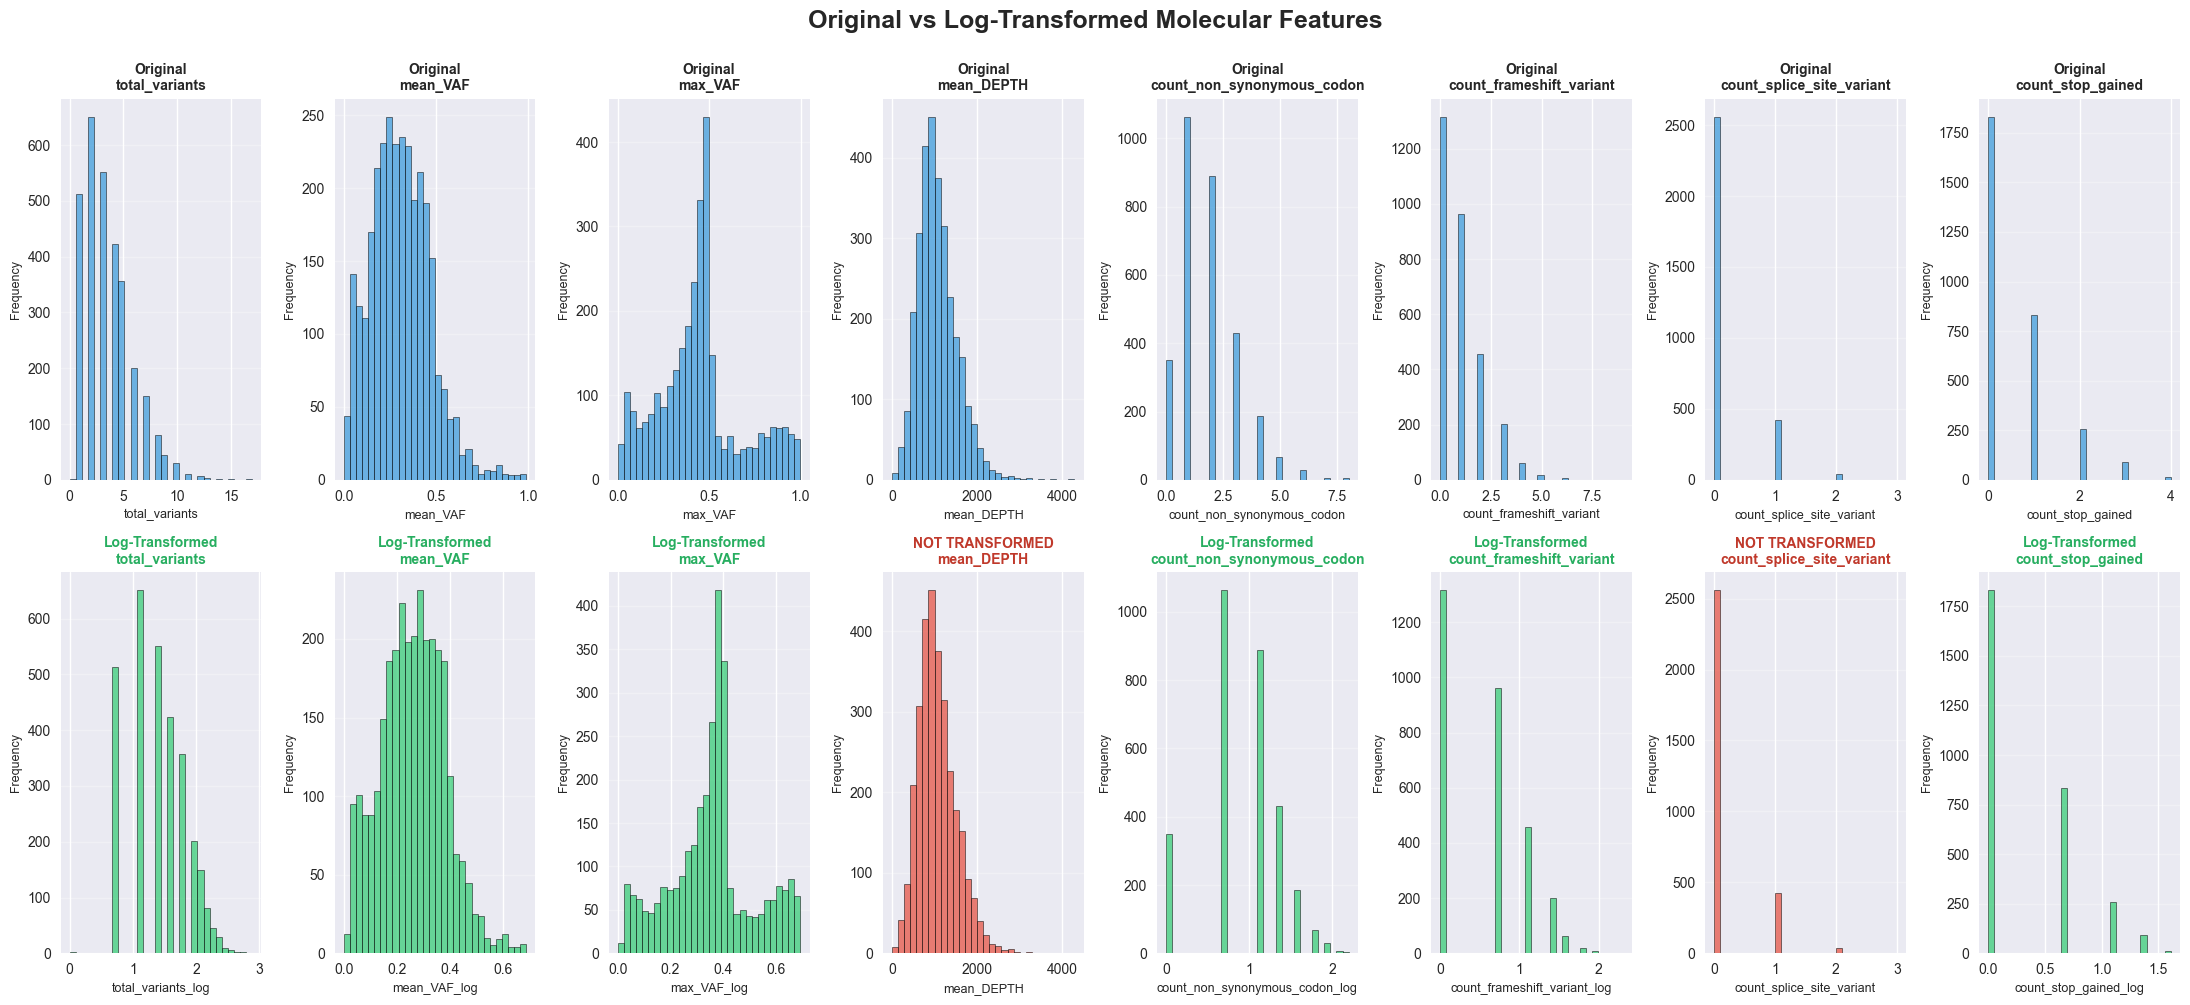

In [13]:
# Data Transformation - Log Transformation for Molecular Variables
# Apply log(x + 1) transformation to reduce skewness (excluding sparse/over-transformed variables)
molecular_features = ['total_variants', 'mean_VAF', 'max_VAF', 'mean_DEPTH',
                      'count_non_synonymous_codon', 'count_frameshift_variant', 
                      'count_splice_site_variant', 'count_stop_gained']

# Features to transform (excluding count_splice_site_variant: too sparse, mean_DEPTH: over-transformed)
features_to_transform = ['total_variants', 'mean_VAF', 'max_VAF',
                         'count_non_synonymous_codon', 'count_frameshift_variant', 
                         'count_stop_gained']

# Create transformed dataframe
molecular_transformed = molecular_agg.copy()
for col in features_to_transform:
    molecular_transformed[f'{col}_log'] = np.log1p(molecular_agg[col])

print("Original vs Log-transformed Distributions (6 variables transformed, 2 kept original):")

# Enhanced titles with descriptions
transform_titles = [
    'Total Variants (TRANSFORMED)',
    'Mean VAF (TRANSFORMED)',
    'Max VAF (TRANSFORMED)',
    'Mean Depth (NOT TRANSFORMED)',
    'Non-synonymous Codons (TRANSFORMED)',
    'Frameshift Variants (TRANSFORMED)',
    'Splice Site Variants (NOT TRANSFORMED)',
    'Stop Gained (TRANSFORMED)'
]

fig, axes = plt.subplots(2, len(molecular_features), figsize=(22, 10))
fig.suptitle('Original vs Log-Transformed Molecular Features', fontsize=18, fontweight='bold', y=1.00)

for i, col in enumerate(molecular_features):
    # Original (top row)
    axes[0, i].hist(molecular_agg[col].dropna(), bins=30, alpha=0.7, color='#3498db', edgecolor='black', linewidth=0.5)
    axes[0, i].set_title(f'Original\n{col}', fontsize=10, fontweight='bold')
    axes[0, i].set_xlabel(col, fontsize=9)
    axes[0, i].set_ylabel('Frequency', fontsize=9)
    axes[0, i].grid(axis='y', alpha=0.3)
    
    # Transformed (bottom row)
    if col in features_to_transform:
        axes[1, i].hist(molecular_transformed[f'{col}_log'].dropna(), bins=30, alpha=0.7, color='#2ecc71', edgecolor='black', linewidth=0.5)
        axes[1, i].set_title(f'Log-Transformed\n{col}', fontsize=10, fontweight='bold', color='#27ae60')
        axes[1, i].set_xlabel(f'{col}_log', fontsize=9)
    else:
        axes[1, i].hist(molecular_agg[col].dropna(), bins=30, alpha=0.7, color='#e74c3c', edgecolor='black', linewidth=0.5)
        axes[1, i].set_title(f'NOT TRANSFORMED\n{col}', fontsize=10, fontweight='bold', color='#c0392b')
        axes[1, i].set_xlabel(col, fontsize=9)
    axes[1, i].set_ylabel('Frequency', fontsize=9)
    axes[1, i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()




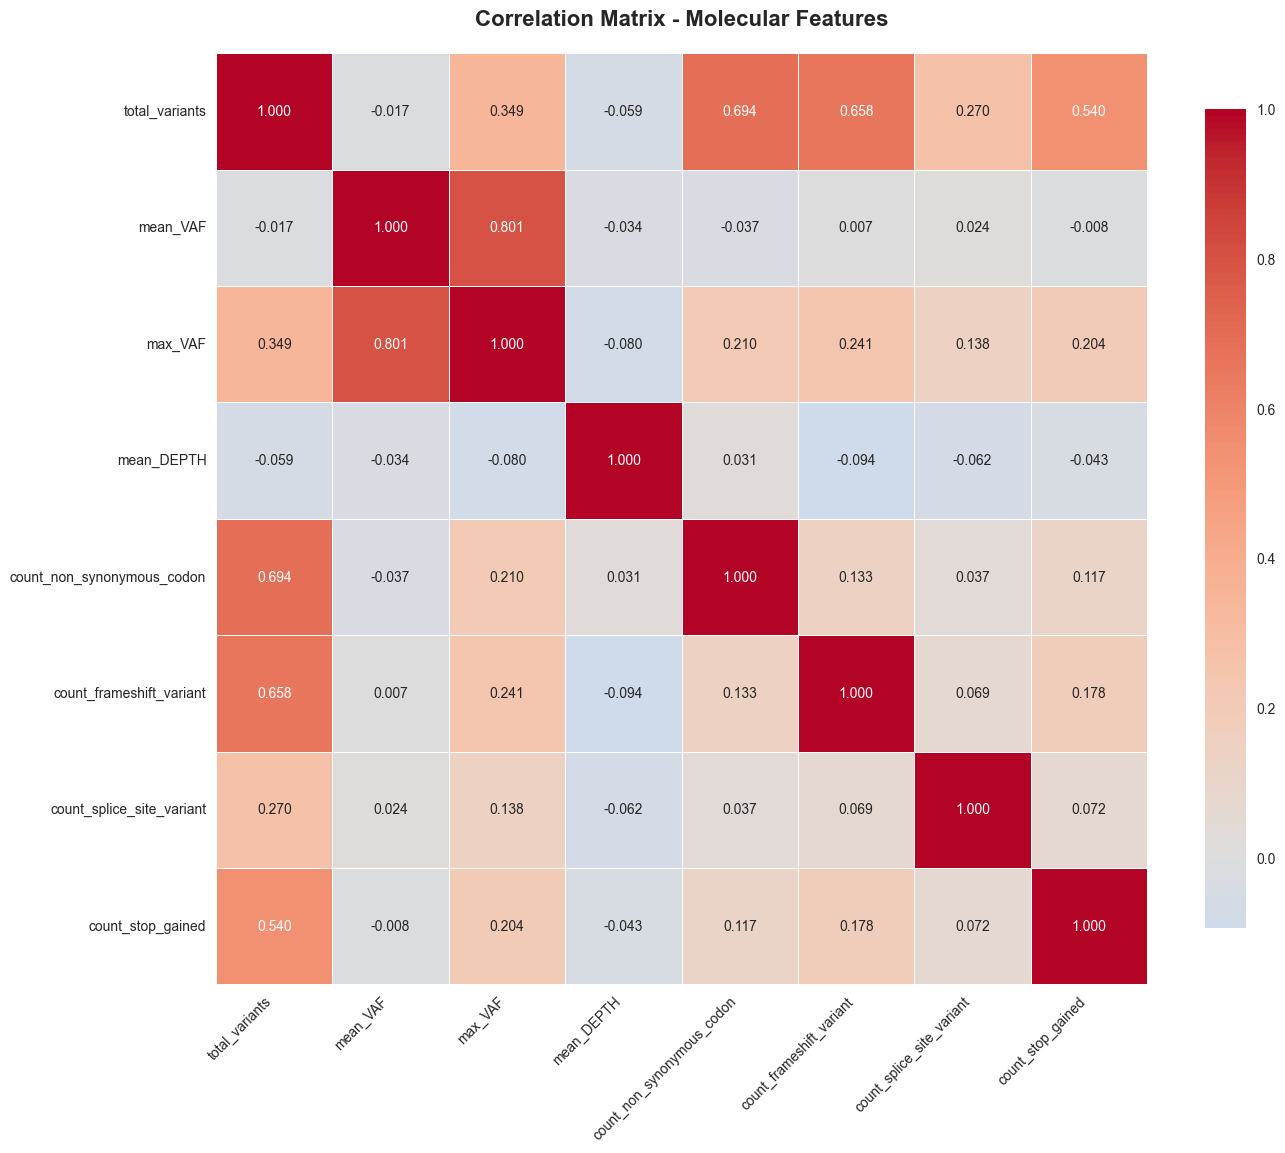

In [14]:
# Correlation Analysis for Molecular Features
molecular_features = ['total_variants', 'mean_VAF', 'max_VAF', 'mean_DEPTH',
                      'count_non_synonymous_codon', 'count_frameshift_variant', 
                      'count_splice_site_variant', 'count_stop_gained']


# Calculate correlation matrix
molecular_corr = molecular_agg[molecular_features].corr()

# Visualize with heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(molecular_corr, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 10})
plt.title('Correlation Matrix - Molecular Features', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


FEATURE ENGINEERING AVANCÉ
✓ Features cliniques créées:
   - Ratios: HB_PLT_ratio, ANC_HB_ratio, BLAST_ANC_ratio
   - Score: severity_score
   - Binaires: HB_low, PLT_low, BLAST_high

✓ Features moléculaires créées:
   - VAF_ratio (clonalité)
   - weighted_mutation_score (charge pondérée)
   - high_mutation_burden (binaire)
   - mutation_diversity (0-4)

✓ Features d'interaction créées:
   - blast_mutation_interaction
   - combined_risk_score

✓ Mêmes features appliquées au test


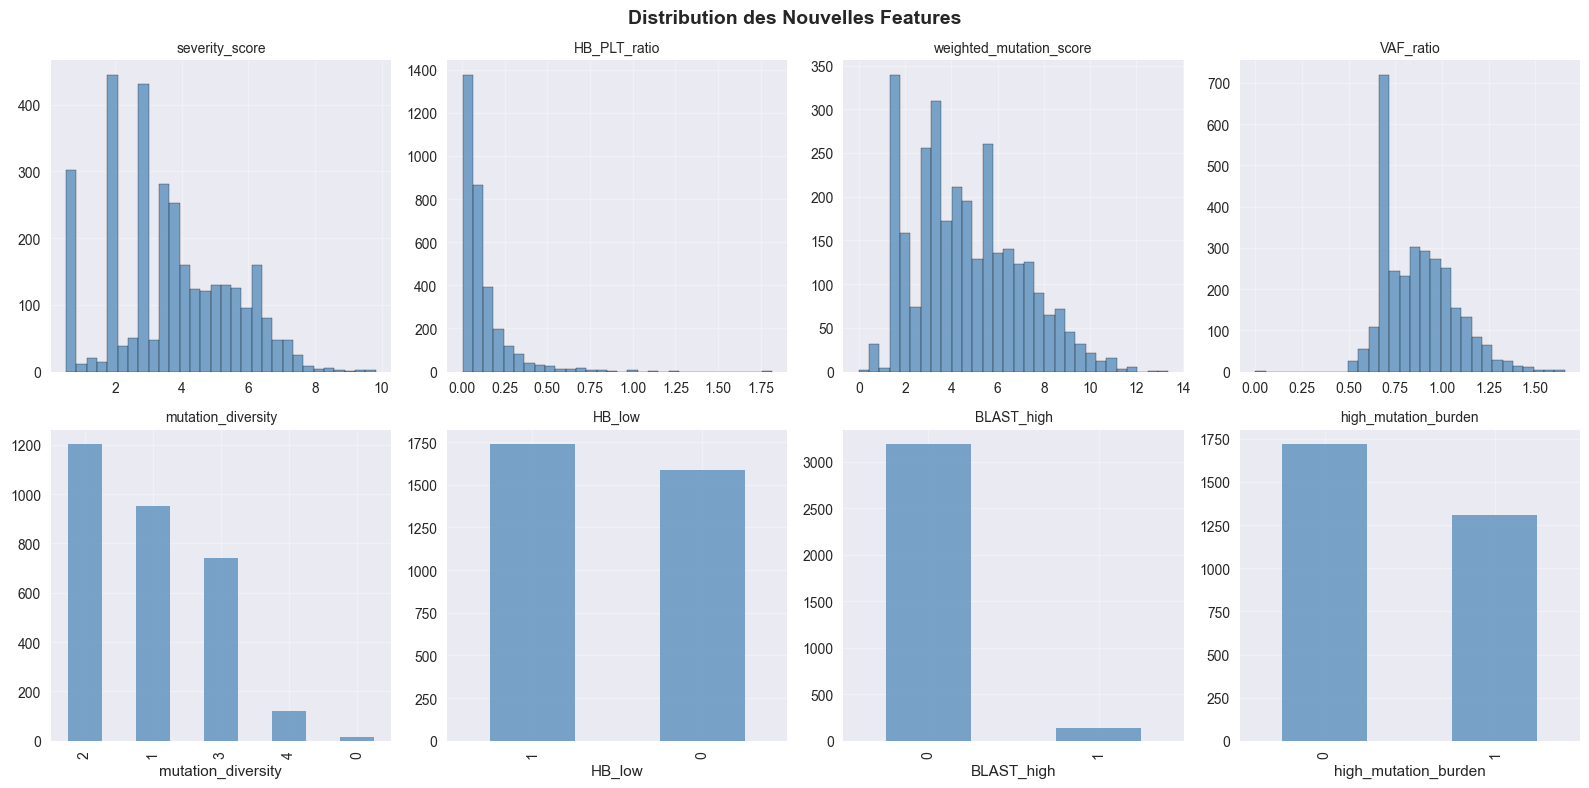


TOTAL NOUVELLES FEATURES: 11
   Cliniques: 6 (3 ratios, 1 score, 3 binaires)
   Moléculaires: 4 (ratio, score, binaire, diversité)
   Interactions: 2 (à ajouter si sélectionnées)


In [15]:
# ============================================================
# FEATURE ENGINEERING AVANCÉ
# ============================================================
# Création de nouvelles features pour améliorer le pouvoir prédictif

print("="*60)
print("FEATURE ENGINEERING AVANCÉ")
print("="*60)

# --- 1. FEATURES CLINIQUES AVANCÉES ---
clinical_eng = clinical_transformed.copy()

# Ratios cliniques (marqueurs de déséquilibre hématologique)
clinical_eng['HB_PLT_ratio'] = np.log1p(clinical_train['HB'] / (clinical_train['PLT'] + 1))
clinical_eng['ANC_HB_ratio'] = np.log1p(clinical_train['ANC'] / (clinical_train['HB'] + 0.1))
clinical_eng['BLAST_ANC_ratio'] = np.log1p(clinical_train['BM_BLAST'] / (clinical_train['ANC'] + 0.1))

# Score de sévérité clinique (combinaison pondérée)
clinical_eng['severity_score'] = (
    clinical_eng['BM_BLAST_log'] * 2 +  # Blastes: facteur pronostique majeur
    (1 / (clinical_eng['HB_log'] + 0.1)) +  # Anémie (HB bas = mauvais)
    (1 / (clinical_eng['PLT_log'] + 0.1))   # Thrombocytopénie (PLT bas = mauvais)
)

# Indicateurs binaires de seuils critiques
clinical_eng['HB_low'] = (clinical_train['HB'] < 10).astype(int)  # Anémie sévère
clinical_eng['PLT_low'] = (clinical_train['PLT'] < 50).astype(int)  # Thrombocytopénie
clinical_eng['BLAST_high'] = (clinical_train['BM_BLAST'] > 20).astype(int)  # Blastes élevés

print("✓ Features cliniques créées:")
print("   - Ratios: HB_PLT_ratio, ANC_HB_ratio, BLAST_ANC_ratio")
print("   - Score: severity_score")
print("   - Binaires: HB_low, PLT_low, BLAST_high")

# --- 2. FEATURES MOLÉCULAIRES AVANCÉES ---
molecular_eng = molecular_transformed.copy()

# Ratio VAF (clonalité tumorale)
molecular_eng['VAF_ratio'] = np.log1p(molecular_agg['max_VAF'] / (molecular_agg['mean_VAF'] + 0.01))

# Score de charge mutationnelle pondérée (mutations graves comptent plus)
molecular_eng['weighted_mutation_score'] = (
    molecular_eng['total_variants_log'] +
    molecular_eng['count_non_synonymous_codon_log'] * 1.5 +
    np.log1p(molecular_agg['count_frameshift_variant']) * 2 +
    np.log1p(molecular_agg['count_stop_gained']) * 2.5
)

# Indicateur de charge mutationnelle élevée
median_variants = molecular_agg['total_variants'].median()
molecular_eng['high_mutation_burden'] = (molecular_agg['total_variants'] > median_variants).astype(int)

# Diversité mutationnelle (nombre de types d'effets différents présents)
molecular_eng['mutation_diversity'] = (
    (molecular_agg['count_non_synonymous_codon'] > 0).astype(int) +
    (molecular_agg['count_frameshift_variant'] > 0).astype(int) +
    (molecular_agg['count_splice_site_variant'] > 0).astype(int) +
    (molecular_agg['count_stop_gained'] > 0).astype(int)
)

print("\n✓ Features moléculaires créées:")
print("   - VAF_ratio (clonalité)")
print("   - weighted_mutation_score (charge pondérée)")
print("   - high_mutation_burden (binaire)")
print("   - mutation_diversity (0-4)")

# --- 3. FEATURES D'INTERACTION CLINIQUE × MOLÉCULAIRE ---
# Merge temporaire pour créer interactions
temp_merged = clinical_eng.merge(molecular_eng[['ID', 'total_variants_log', 'weighted_mutation_score', 
                                                  'high_mutation_burden', 'VAF_ratio']], on='ID', how='inner')

# Interaction blastes × mutations
temp_merged['blast_mutation_interaction'] = temp_merged['BM_BLAST_log'] * temp_merged['total_variants_log']

# Score de risque combiné
temp_merged['combined_risk_score'] = (
    temp_merged['severity_score'] + 
    temp_merged['weighted_mutation_score']
)

print("\n✓ Features d'interaction créées:")
print("   - blast_mutation_interaction")
print("   - combined_risk_score")

# --- 4. APPLICATION AU TEST ---
# D'abord créer les transformations log pour le test (comme pour le train)
clinical_transformed_test = clinical_test.copy()
for col in ['BM_BLAST', 'ANC', 'MONOCYTES', 'HB', 'PLT']:
    clinical_transformed_test[f'{col}_log'] = np.log1p(clinical_test[col])

molecular_transformed_test = molecular_agg_test.copy()
for col in ['total_variants', 'mean_VAF', 'max_VAF', 'count_non_synonymous_codon', 'count_frameshift_variant', 'count_stop_gained']:
    molecular_transformed_test[f'{col}_log'] = np.log1p(molecular_agg_test[col])

clinical_eng_test = clinical_transformed_test.copy()

# Mêmes transformations pour test
clinical_eng_test['HB_PLT_ratio'] = np.log1p(clinical_test['HB'] / (clinical_test['PLT'] + 1))
clinical_eng_test['ANC_HB_ratio'] = np.log1p(clinical_test['ANC'] / (clinical_test['HB'] + 0.1))
clinical_eng_test['BLAST_ANC_ratio'] = np.log1p(clinical_test['BM_BLAST'] / (clinical_test['ANC'] + 0.1))

clinical_eng_test['severity_score'] = (
    clinical_eng_test['BM_BLAST_log'] * 2 +
    (1 / (clinical_eng_test['HB_log'] + 0.1)) +
    (1 / (clinical_eng_test['PLT_log'] + 0.1))
)

clinical_eng_test['HB_low'] = (clinical_test['HB'] < 10).astype(int)
clinical_eng_test['PLT_low'] = (clinical_test['PLT'] < 50).astype(int)
clinical_eng_test['BLAST_high'] = (clinical_test['BM_BLAST'] > 20).astype(int)

molecular_eng_test = molecular_transformed_test.copy()
molecular_eng_test['VAF_ratio'] = np.log1p(molecular_agg_test['max_VAF'] / (molecular_agg_test['mean_VAF'] + 0.01))
molecular_eng_test['weighted_mutation_score'] = (
    molecular_eng_test['total_variants_log'] +
    molecular_eng_test['count_non_synonymous_codon_log'] * 1.5 +
    np.log1p(molecular_agg_test['count_frameshift_variant']) * 2 +
    np.log1p(molecular_agg_test['count_stop_gained']) * 2.5
)
molecular_eng_test['high_mutation_burden'] = (molecular_agg_test['total_variants'] > median_variants).astype(int)
molecular_eng_test['mutation_diversity'] = (
    (molecular_agg_test['count_non_synonymous_codon'] > 0).astype(int) +
    (molecular_agg_test['count_frameshift_variant'] > 0).astype(int) +
    (molecular_agg_test['count_splice_site_variant'] > 0).astype(int) +
    (molecular_agg_test['count_stop_gained'] > 0).astype(int)
)

print("\n✓ Mêmes features appliquées au test")

# --- 5. VISUALISATION DES NOUVELLES FEATURES ---
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Distribution des Nouvelles Features', fontsize=14, fontweight='bold')

new_features_plot = [
    ('severity_score', clinical_eng),
    ('HB_PLT_ratio', clinical_eng),
    ('weighted_mutation_score', molecular_eng),
    ('VAF_ratio', molecular_eng),
    ('mutation_diversity', molecular_eng),
    ('HB_low', clinical_eng),
    ('BLAST_high', clinical_eng),
    ('high_mutation_burden', molecular_eng)
]

for idx, (feat, df) in enumerate(new_features_plot):
    ax = axes[idx // 4, idx % 4]
    if feat in ['HB_low', 'PLT_low', 'BLAST_high', 'high_mutation_burden', 'mutation_diversity']:
        df[feat].value_counts().plot(kind='bar', ax=ax, color='steelblue', alpha=0.7)
    else:
        ax.hist(df[feat].dropna(), bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    ax.set_title(feat, fontsize=10)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print(f"TOTAL NOUVELLES FEATURES: 11")
print("   Cliniques: 6 (3 ratios, 1 score, 3 binaires)")
print("   Moléculaires: 4 (ratio, score, binaire, diversité)")
print("   Interactions: 2 (à ajouter si sélectionnées)")
print("="*60)

In [16]:
# Construction du Dataset Final (37 features)
# ============================================

# --- Listes de features ---
clinical_features_final = ['BM_BLAST_log', 'ANC_log', 'HB_log', 'PLT_log']
clinical_eng_features = ['severity_score', 'HB_PLT_ratio', 'BLAST_ANC_ratio', 'HB_low', 'BLAST_high']
molecular_features_final = ['total_variants_log', 'max_VAF_log', 'count_non_synonymous_codon_log']
molecular_eng_features = ['weighted_mutation_score', 'VAF_ratio', 'high_mutation_burden', 'mutation_diversity']
cyto_features = ['is_normal_karyotype', 'has_monosomy_7', 'has_del5q', 'has_del7q', 
                 'has_trisomy_8', 'has_del20q', 'is_complex_karyotype', 'cyto_risk_score']
gene_features = ['has_TP53', 'has_ASXL1', 'has_RUNX1', 'has_EZH2', 'has_SF3B1', 
                 'has_SRSF2', 'has_TET2', 'has_DNMT3A',
                 'n_high_risk_genes', 'n_splicing_genes', 'n_epigenetic_genes', 
                 'n_signaling_genes', 'n_unique_genes']

# --- Construction ---
clinical_cols = clinical_features_final + clinical_eng_features
molecular_cols = molecular_features_final + molecular_eng_features

final_train = clinical_eng[['ID'] + clinical_cols].merge(
    molecular_eng[['ID'] + molecular_cols], on='ID', how='inner')
final_train = final_train.merge(cyto_features_train[['ID'] + cyto_features], on='ID', how='left')
final_train = final_train.merge(gene_features_train[['ID'] + gene_features], on='ID', how='left')
final_train = final_train.merge(target_train[['ID', 'OS_YEARS', 'OS_STATUS']], on='ID', how='inner')

all_features = clinical_cols + molecular_cols + cyto_features + gene_features
print(f"📊 Dataset: {len(final_train)} obs × {len(all_features)} features")

📊 Dataset: 3026 obs × 37 features


In [17]:
# Imputation KNN
# Note: all_features est déjà défini dans la cellule précédente avec toutes les features (originales + engineered)
from sklearn.impute import KNNImputer

print(f"Features à imputer: {len(all_features)}")
print(f"NaN avant imputation: {final_train[all_features].isnull().sum().sum()}")

knn_imputer = KNNImputer(n_neighbors=5)
final_train[all_features] = knn_imputer.fit_transform(final_train[all_features])

print(f"NaN après imputation: {final_train[all_features].isnull().sum().sum()}")

Features à imputer: 37
NaN avant imputation: 961
NaN après imputation: 0


In [18]:
# Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
final_train_scaled = final_train.copy()
final_train_scaled[all_features] = scaler.fit_transform(final_train[all_features])

# Remove rows with missing OS_YEARS or OS_STATUS
final_train_clean = final_train_scaled.dropna(subset=['OS_YEARS', 'OS_STATUS'])

display(final_train_clean.head())

,ID,BM_BLAST_log,ANC_log,HB_log,PLT_log,severity_score,HB_PLT_ratio,BLAST_ANC_ratio,HB_low,BLAST_high,...,has_SRSF2,has_TET2,has_DNMT3A,n_high_risk_genes,n_splicing_genes,n_epigenetic_genes,n_signaling_genes,n_unique_genes,OS_YEARS,OS_STATUS
0,P132697,1.276906,-1.522242,-1.154806,0.052749,1.282696,-0.453738,2.429859,0.941559,-0.21693,...,-0.482272,1.389004,2.160247,1.747268,0.766576,2.416566,1.626114,2.720586,1.115068,1.0
1,P132698,-0.978651,0.073806,0.868725,-1.050970,-0.960588,0.905258,-0.822424,-1.062068,-0.21693,...,-0.482272,-0.719940,-0.462910,1.747268,-1.083232,0.037734,-0.445726,-0.056908,4.928767,0.0
2,P116889,1.349153,-0.067758,1.862642,-0.356750,1.314189,0.299207,0.763245,-1.062068,-0.21693,...,-0.482272,-0.719940,-0.462910,0.458328,0.766576,0.037734,-0.445726,-0.056908,2.043836,0.0
3,P132699,-0.978651,-0.169964,-0.408978,-0.410534,-0.958552,-0.096492,-0.758818,0.941559,-0.21693,...,-0.482272,-0.719940,-0.462910,3.036209,0.766576,1.227150,-0.445726,3.276085,2.476712,1.0
4,P132700,0.423738,1.830790,0.654197,0.580387,0.393440,-0.502157,-0.692291,-1.062068,-0.21693,...,-0.482272,-0.719940,-0.462910,0.458328,-1.083232,0.037734,-0.445726,-1.167906,3.145205,0.0


In [19]:
# Préparation Test (37 features)
# ===============================

final_test = clinical_eng_test[['ID'] + clinical_cols].merge(
    molecular_eng_test[['ID'] + molecular_cols], on='ID', how='inner')
final_test = final_test.merge(cyto_features_test[['ID'] + cyto_features], on='ID', how='left')
final_test = final_test.merge(gene_features_test[['ID'] + gene_features], on='ID', how='left')

# Imputation + Standardisation
from sklearn.impute import KNNImputer
knn_imputer_test = KNNImputer(n_neighbors=5)
knn_imputer_test.fit(final_train[all_features])
final_test[all_features] = knn_imputer_test.transform(final_test[all_features])
final_test_scaled = final_test.copy()
final_test_scaled[all_features] = scaler.transform(final_test[all_features])

print(f"✓ Test: {final_test.shape[0]} obs × {len(all_features)} features")

✓ Test: 1054 obs × 37 features


In [20]:
# Modele Cox - Baseline avec CoxPHSurvivalAnalysis (sksurv)
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_ipcw
from sksurv.util import Surv

# Use final_train_clean that was already properly prepared
print(f"Dataset: {final_train_clean.shape}")
print(f"Features: {len(all_features)}")

# Préparation données pour sksurv
y_train = Surv.from_arrays(event=final_train_clean['OS_STATUS'].astype(bool), time=final_train_clean['OS_YEARS'])

# Fit Cox model
cox_model = CoxPHSurvivalAnalysis()
cox_model.fit(final_train_clean[all_features], y_train)

# Evaluation avec IPCW C-index
risk_scores = cox_model.predict(final_train_clean[all_features])
c_index_ipcw = concordance_index_ipcw(y_train, y_train, risk_scores, tau=7)[0]

print(f"\nC-index IPCW (train): {c_index_ipcw:.4f}")
print(f"\nCoefficients du modèle:")
for feat, coef in zip(all_features, cox_model.coef_):
    print(f"   {feat}: {coef:.4f}")

Dataset: (2910, 40)
Features: 37

C-index IPCW (train): 0.7171

Coefficients du modèle:
   BM_BLAST_log: 0.7745
   ANC_log: 0.2007
   HB_log: -0.2008
   PLT_log: -0.2682
   severity_score: -0.7496
   HB_PLT_ratio: -0.0383
   BLAST_ANC_ratio: 0.2630
   HB_low: 0.0757
   BLAST_high: -0.0515
   total_variants_log: 0.1859
   max_VAF_log: 0.1395
   count_non_synonymous_codon_log: -0.0113
   weighted_mutation_score: -0.0814
   VAF_ratio: -0.0155
   high_mutation_burden: -0.0063
   mutation_diversity: -0.0576
   is_normal_karyotype: -0.1912
   has_monosomy_7: 0.0674
   has_del5q: -0.0046
   has_del7q: 0.0633
   has_trisomy_8: -0.0119
   has_del20q: -0.0019
   is_complex_karyotype: 0.0121
   cyto_risk_score: 0.0331
   has_TP53: 9.1226
   has_ASXL1: 12.2622
   has_RUNX1: 9.6881
   has_EZH2: 6.8870
   has_SF3B1: -0.0489
   has_SRSF2: 0.0583
   has_TET2: -0.0941
   has_DNMT3A: 0.0647
   n_high_risk_genes: -20.7296
   n_splicing_genes: 0.0326
   n_epigenetic_genes: 0.0527
   n_signaling_genes: 0.0

In [21]:
# Validation croisée 10-fold pour estimation réaliste
from sklearn.model_selection import KFold

kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(final_train), 1):
    # Split
    train_fold = final_train.iloc[train_idx].copy()
    val_fold = final_train.iloc[val_idx].copy()
    
    # Imputation (fit sur train, transform sur val)
    knn = KNNImputer(n_neighbors=5)
    train_fold[all_features] = knn.fit_transform(train_fold[all_features])
    val_fold[all_features] = knn.transform(val_fold[all_features])
    
    # Standardisation
    sc = StandardScaler()
    train_fold[all_features] = sc.fit_transform(train_fold[all_features])
    val_fold[all_features] = sc.transform(val_fold[all_features])
    
    # Nettoyage
    train_fold = train_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
    val_fold = val_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
    
    # Préparation données pour sksurv
    y_train_fold = Surv.from_arrays(train_fold['OS_STATUS'].astype(bool), train_fold['OS_YEARS'])
    y_val_fold = Surv.from_arrays(val_fold['OS_STATUS'].astype(bool), val_fold['OS_YEARS'])
    
    # Modèle Cox (sksurv)
    cox = CoxPHSurvivalAnalysis()
    cox.fit(train_fold[all_features], y_train_fold)
    
    # C-index IPCW sur validation
    scores = cox.predict(val_fold[all_features])
    
    c_index = concordance_index_ipcw(y_train_fold, y_val_fold, scores, tau=7)[0]
    cv_scores.append(c_index)
    

print(f"IPCW C-index (validation croisée 10-fold): {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

IPCW C-index (validation croisée 10-fold): 0.7093 ± 0.0177


α=0.001: C-index CV = 0.7096 ± 0.0111
α=0.01 : C-index CV = 0.7112 ± 0.0123
α=0.05 : C-index CV = 0.7089 ± 0.0141
α=0.1  : C-index CV = 0.7020 ± 0.0150
α=0.2  : C-index CV = 0.6300 ± 0.0177
α=0.5  : C-index CV = 0.5000 ± 0.0000
α=1.0  : C-index CV = 0.5000 ± 0.0000


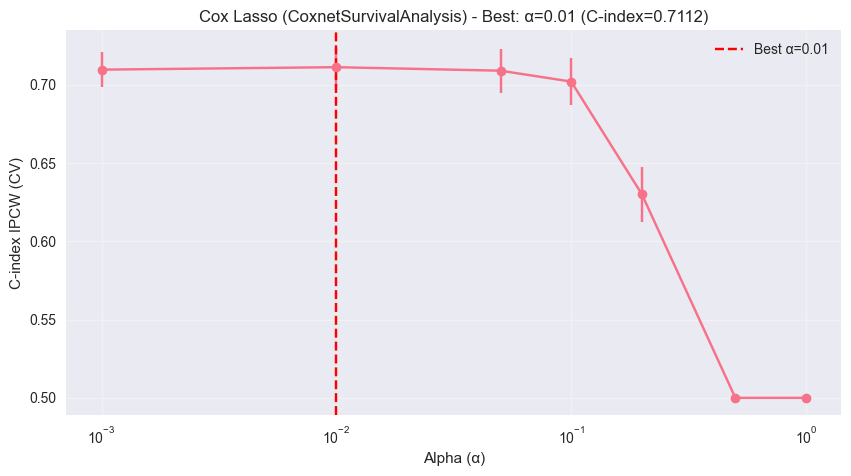


✓ Meilleur alpha Lasso: α = 0.01
✓ C-index CV Lasso: 0.7112


In [22]:
# Cox avec régularisation Lasso (L1) - Recherche du meilleur alpha
from sklearn.model_selection import KFold
from sksurv.linear_model import CoxnetSurvivalAnalysis

alphas = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
results_lasso = []

for alpha in alphas:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores_pen = []
    
    for train_idx, val_idx in kf.split(final_train):
        train_fold = final_train.iloc[train_idx].copy()
        val_fold = final_train.iloc[val_idx].copy()
        
        # Imputation
        knn = KNNImputer(n_neighbors=5)
        train_fold[all_features] = knn.fit_transform(train_fold[all_features])
        val_fold[all_features] = knn.transform(val_fold[all_features])
        
        # Standardisation
        sc = StandardScaler()
        train_fold[all_features] = sc.fit_transform(train_fold[all_features])
        val_fold[all_features] = sc.transform(val_fold[all_features])
        
        train_fold = train_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
        val_fold = val_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
        
        # Préparation données
        y_tr = Surv.from_arrays(train_fold['OS_STATUS'].astype(bool), train_fold['OS_YEARS'])
        y_val = Surv.from_arrays(val_fold['OS_STATUS'].astype(bool), val_fold['OS_YEARS'])
        
        # Cox Lasso (L1) avec CoxnetSurvivalAnalysis
        cox_lasso = CoxnetSurvivalAnalysis(l1_ratio=1.0, alphas=[alpha], fit_baseline_model=True)
        cox_lasso.fit(train_fold[all_features], y_tr)
        
        # C-index IPCW
        scores = cox_lasso.predict(val_fold[all_features])
        c_index = concordance_index_ipcw(y_tr, y_val, scores, tau=7)[0]
        cv_scores_pen.append(c_index)
    
    mean_score = np.mean(cv_scores_pen)
    std_score = np.std(cv_scores_pen)
    results_lasso.append({'alpha': alpha, 'mean': mean_score, 'std': std_score})
    print(f"α={alpha:<5}: C-index CV = {mean_score:.4f} ± {std_score:.4f}")

# Meilleur alpha
results_lasso_df = pd.DataFrame(results_lasso)
best_alpha = results_lasso_df.loc[results_lasso_df['mean'].idxmax(), 'alpha']
best_score_lasso = results_lasso_df['mean'].max()

plt.figure(figsize=(10, 5))
plt.errorbar(results_lasso_df['alpha'], results_lasso_df['mean'], 
             yerr=results_lasso_df['std'], fmt='o-', capsize=3)
plt.xscale('log')
plt.axvline(best_alpha, color='r', linestyle='--', label=f'Best α={best_alpha}')
plt.xlabel('Alpha (α)')
plt.ylabel('C-index IPCW (CV)')
plt.title(f'Cox Lasso (CoxnetSurvivalAnalysis) - Best: α={best_alpha} (C-index={best_score_lasso:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\n✓ Meilleur alpha Lasso: α = {best_alpha}")
print(f"✓ C-index CV Lasso: {best_score_lasso:.4f}")

α=0.001: C-index CV = 0.7093 ± 0.0111
α=0.01 : C-index CV = 0.7095 ± 0.0112
α=0.05 : C-index CV = 0.7100 ± 0.0119
α=0.1  : C-index CV = 0.7102 ± 0.0122
α=0.2  : C-index CV = 0.7104 ± 0.0124
α=0.5  : C-index CV = 0.7099 ± 0.0129
α=1.0  : C-index CV = 0.7085 ± 0.0131


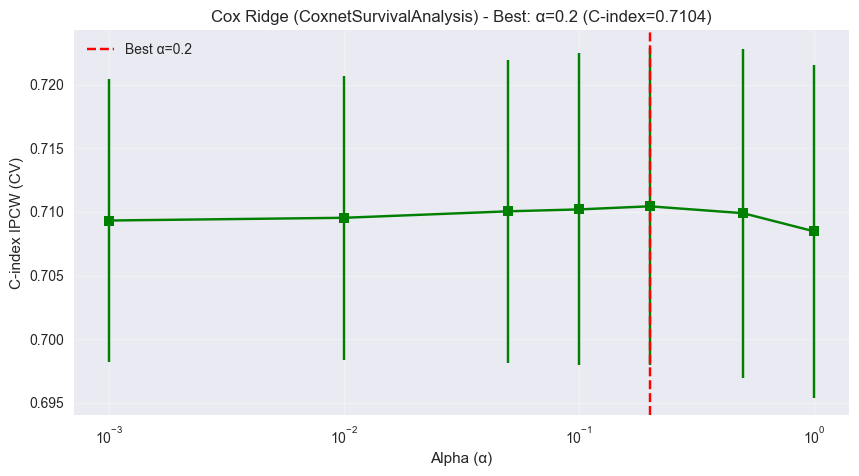


✓ Meilleur alpha Ridge: α = 0.2
✓ C-index CV Ridge: 0.7104

📊 Comparaison Lasso vs Ridge:
   Lasso (L1): α=0.01, C-index=0.7112
   Ridge (L2≈): α=0.2, C-index=0.7104


In [23]:
# Cox avec régularisation Ridge (L2) - Recherche du meilleur alpha
# Note: CoxnetSurvivalAnalysis requiert l1_ratio > 0, on utilise 0.01 pour approximer Ridge
alphas_ridge = [0.001, 0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
results_ridge = []

for alpha in alphas_ridge:
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores_pen = []
    
    for train_idx, val_idx in kf.split(final_train):
        train_fold = final_train.iloc[train_idx].copy()
        val_fold = final_train.iloc[val_idx].copy()
        
        # Imputation
        knn = KNNImputer(n_neighbors=5)
        train_fold[all_features] = knn.fit_transform(train_fold[all_features])
        val_fold[all_features] = knn.transform(val_fold[all_features])
        
        # Standardisation
        sc = StandardScaler()
        train_fold[all_features] = sc.fit_transform(train_fold[all_features])
        val_fold[all_features] = sc.transform(val_fold[all_features])
        
        train_fold = train_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
        val_fold = val_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
        
        # Préparation données
        y_tr = Surv.from_arrays(train_fold['OS_STATUS'].astype(bool), train_fold['OS_YEARS'])
        y_val = Surv.from_arrays(val_fold['OS_STATUS'].astype(bool), val_fold['OS_YEARS'])
        
        # Cox Ridge (quasi-L2) avec CoxnetSurvivalAnalysis - l1_ratio=0.01 (proche de Ridge)
        cox_ridge = CoxnetSurvivalAnalysis(l1_ratio=0.01, alphas=[alpha], fit_baseline_model=True)
        cox_ridge.fit(train_fold[all_features], y_tr)
        
        # C-index IPCW
        scores = cox_ridge.predict(val_fold[all_features])
        c_index = concordance_index_ipcw(y_tr, y_val, scores, tau=7)[0]
        cv_scores_pen.append(c_index)
    
    mean_score = np.mean(cv_scores_pen)
    std_score = np.std(cv_scores_pen)
    results_ridge.append({'alpha': alpha, 'mean': mean_score, 'std': std_score})
    print(f"α={alpha:<5}: C-index CV = {mean_score:.4f} ± {std_score:.4f}")

# Meilleur alpha Ridge
results_ridge_df = pd.DataFrame(results_ridge)
best_alpha_ridge = results_ridge_df.loc[results_ridge_df['mean'].idxmax(), 'alpha']
best_score_ridge = results_ridge_df['mean'].max()

plt.figure(figsize=(10, 5))
plt.errorbar(results_ridge_df['alpha'], results_ridge_df['mean'], 
             yerr=results_ridge_df['std'], fmt='s-', capsize=3, color='green')
plt.xscale('log')
plt.axvline(best_alpha_ridge, color='r', linestyle='--', label=f'Best α={best_alpha_ridge}')
plt.xlabel('Alpha (α)')
plt.ylabel('C-index IPCW (CV)')
plt.title(f'Cox Ridge (CoxnetSurvivalAnalysis) - Best: α={best_alpha_ridge} (C-index={best_score_ridge:.4f})')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"\n✓ Meilleur alpha Ridge: α = {best_alpha_ridge}")
print(f"✓ C-index CV Ridge: {best_score_ridge:.4f}")
print(f"\n📊 Comparaison Lasso vs Ridge:")
print(f"   Lasso (L1): α={best_alpha}, C-index={best_score_lasso:.4f}")
print(f"   Ridge (L2≈): α={best_alpha_ridge}, C-index={best_score_ridge:.4f}")

In [24]:
# Random Survival Forest (RSF) avec tuning des hyperparamètres
from sksurv.ensemble import RandomSurvivalForest

# Grille d'hyperparamètres à tester
n_estimators_list = [100, 200]
max_depth_list = [3, 5, 7, None]
min_samples_split_list = [6, 10]

results_rsf = []

for n_est in n_estimators_list:
    for max_d in max_depth_list:
        for min_split in min_samples_split_list:
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores_rsf = []
            
            for train_idx, val_idx in kf.split(final_train):
                train_fold = final_train.iloc[train_idx].copy()
                val_fold = final_train.iloc[val_idx].copy()
                
                # Imputation
                knn = KNNImputer(n_neighbors=5)
                train_fold[all_features] = knn.fit_transform(train_fold[all_features])
                val_fold[all_features] = knn.transform(val_fold[all_features])
                
                # Standardisation (optionnelle pour RSF mais garde cohérence)
                sc = StandardScaler()
                train_fold[all_features] = sc.fit_transform(train_fold[all_features])
                val_fold[all_features] = sc.transform(val_fold[all_features])
                
                train_fold = train_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
                val_fold = val_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
                
                # Préparation données pour sksurv
                y_tr = Surv.from_arrays(train_fold['OS_STATUS'].astype(bool), train_fold['OS_YEARS'])
                y_val = Surv.from_arrays(val_fold['OS_STATUS'].astype(bool), val_fold['OS_YEARS'])
                
                # RSF
                rsf = RandomSurvivalForest(
                    n_estimators=n_est,
                    max_depth=max_d,
                    min_samples_split=min_split,
                    n_jobs=-1,
                    random_state=42
                )
                rsf.fit(train_fold[all_features], y_tr)
                
                # Prédiction (risk scores)
                scores = rsf.predict(val_fold[all_features])
                c_index = concordance_index_ipcw(y_tr, y_val, scores, tau=7)[0]
                cv_scores_rsf.append(c_index)
            
            mean_score = np.mean(cv_scores_rsf)
            std_score = np.std(cv_scores_rsf)
            results_rsf.append({
                'n_estimators': n_est, 
                'max_depth': max_d, 
                'min_samples_split': min_split,
                'mean': mean_score, 
                'std': std_score
            })
            print(f"n_est={n_est}, max_depth={max_d}, min_split={min_split}: C-index = {mean_score:.4f} ± {std_score:.4f}")

# Meilleur modèle RSF
results_rsf_df = pd.DataFrame(results_rsf)
best_idx_rsf = results_rsf_df['mean'].idxmax()
best_rsf = results_rsf_df.loc[best_idx_rsf]
best_score_rsf = best_rsf['mean']

print(f"\n✓ Meilleur RSF:")
print(f"   n_estimators = {int(best_rsf['n_estimators'])}")
print(f"   max_depth = {best_rsf['max_depth']}")
print(f"   min_samples_split = {int(best_rsf['min_samples_split'])}")
print(f"   C-index CV = {best_score_rsf:.4f}")

# Visualisation
fig, ax = plt.subplots(figsize=(12, 6))
x_labels = [f"n={r['n_estimators']}\nd={r['max_depth']}\nms={r['min_samples_split']}" 
            for _, r in results_rsf_df.iterrows()]
bars = ax.bar(range(len(results_rsf_df)), results_rsf_df['mean'], 
              yerr=results_rsf_df['std'], capsize=3, alpha=0.7, color='steelblue')
ax.axhline(best_score_rsf, color='r', linestyle='--', label=f'Best = {best_score_rsf:.4f}')
ax.set_xticks(range(len(results_rsf_df)))
ax.set_xticklabels(x_labels, fontsize=8, rotation=45)
ax.set_xlabel('Hyperparamètres')
ax.set_ylabel('C-index IPCW (CV)')
ax.set_title('Random Survival Forest - Tuning')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"\n📊 Comparaison modèles:")
print(f"   Cox baseline:  ~0.64")
print(f"   Cox Lasso:     {best_score_lasso:.4f}")
print(f"   Cox Ridge:     {best_score_ridge:.4f}")
print(f"   RSF:           {best_score_rsf:.4f}")

n_est=100, max_depth=3, min_split=6: C-index = 0.6999 ± 0.0165
n_est=100, max_depth=3, min_split=10: C-index = 0.6999 ± 0.0165
n_est=100, max_depth=5, min_split=6: C-index = 0.7071 ± 0.0157
n_est=100, max_depth=5, min_split=10: C-index = 0.7068 ± 0.0155
n_est=100, max_depth=7, min_split=6: C-index = 0.7113 ± 0.0137
n_est=100, max_depth=7, min_split=10: C-index = 0.7105 ± 0.0135
n_est=100, max_depth=None, min_split=6: C-index = 0.7080 ± 0.0124
n_est=100, max_depth=None, min_split=10: C-index = 0.7109 ± 0.0144
n_est=200, max_depth=3, min_split=6: C-index = 0.7013 ± 0.0156
n_est=200, max_depth=3, min_split=10: C-index = 0.7012 ± 0.0156
n_est=200, max_depth=5, min_split=6: C-index = 0.7080 ± 0.0143


KeyboardInterrupt: 

In [ ]:
# Gradient Boosting Survival Analysis - Grille réduite (basée sur résultats partiels)
from sksurv.ensemble import GradientBoostingSurvivalAnalysis

# Grille réduite (les meilleurs étaient n_est=200, lr=0.05, max_depth=2)
n_estimators_gb = [200]
learning_rates = [0.05,0.1]
max_depths_gb = [2,3]

results_gb = []

for n_est in n_estimators_gb:
    for lr in learning_rates:
        for max_d in max_depths_gb:
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            cv_scores_gb = []
            
            for train_idx, val_idx in kf.split(final_train):
                train_fold = final_train.iloc[train_idx].copy()
                val_fold = final_train.iloc[val_idx].copy()
                
                # Imputation
                knn = KNNImputer(n_neighbors=5)
                train_fold[all_features] = knn.fit_transform(train_fold[all_features])
                val_fold[all_features] = knn.transform(val_fold[all_features])
                
                # Standardisation
                sc = StandardScaler()
                train_fold[all_features] = sc.fit_transform(train_fold[all_features])
                val_fold[all_features] = sc.transform(val_fold[all_features])
                
                train_fold = train_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
                val_fold = val_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
                
                # Préparation données
                y_tr = Surv.from_arrays(train_fold['OS_STATUS'].astype(bool), train_fold['OS_YEARS'])
                y_val = Surv.from_arrays(val_fold['OS_STATUS'].astype(bool), val_fold['OS_YEARS'])
                
                # Gradient Boosting
                gb = GradientBoostingSurvivalAnalysis(
                    n_estimators=n_est,
                    learning_rate=lr,
                    max_depth=max_d,
                    random_state=42
                )
                gb.fit(train_fold[all_features], y_tr)
                
                # Prédiction
                scores = gb.predict(val_fold[all_features])
                c_index = concordance_index_ipcw(y_tr, y_val, scores, tau=7)[0]
                cv_scores_gb.append(c_index)
            
            mean_score = np.mean(cv_scores_gb)
            std_score = np.std(cv_scores_gb)
            results_gb.append({
                'n_estimators': n_est, 
                'learning_rate': lr, 
                'max_depth': max_d,
                'mean': mean_score, 
                'std': std_score
            })
            print(f"n_est={n_est}, lr={lr}, max_depth={max_d}: C-index = {mean_score:.4f} ± {std_score:.4f}")

# Meilleur modèle GB
results_gb_df = pd.DataFrame(results_gb)
best_idx_gb = results_gb_df['mean'].idxmax()
best_gb = results_gb_df.loc[best_idx_gb]
best_score_gb = best_gb['mean']

print(f"\n✓ Meilleur Gradient Boosting:")
print(f"   n_estimators = {int(best_gb['n_estimators'])}")
print(f"   learning_rate = {best_gb['learning_rate']}")
print(f"   max_depth = {int(best_gb['max_depth'])}")
print(f"   C-index CV = {best_score_gb:.4f}")

print(f"\n📊 Comparaison finale des modèles:")
print(f"   Cox Lasso:          {best_score_lasso:.4f}")
print(f"   Cox Ridge:          {best_score_ridge:.4f}")
print(f"   RSF:                {best_score_rsf:.4f}")
print(f"   Gradient Boosting:  {best_score_gb:.4f}")

# Identifier le meilleur modèle global
all_scores = {
    'Cox Lasso': best_score_lasso,
    'Cox Ridge': best_score_ridge,
    'RSF': best_score_rsf,
    'Gradient Boosting': best_score_gb
}
best_model = max(all_scores, key=all_scores.get)
print(f"\n🏆 Meilleur modèle: {best_model} avec C-index = {all_scores[best_model]:.4f}")

n_est=100, lr=0.2, max_depth=2: C-index = 0.7139 ± 0.0169

✓ Meilleur Gradient Boosting:
   n_estimators = 100
   learning_rate = 0.2
   max_depth = 2
   C-index CV = 0.7139

📊 Comparaison finale des modèles:
   Cox Lasso:          0.7112
   Cox Ridge:          0.7104


NameError: name 'best_score_rsf' is not defined

FEATURE IMPORTANCE (Gradient Boosting)
                       feature  importance
             n_high_risk_genes    0.185670
                severity_score    0.138962
                        HB_log    0.122164
                       PLT_log    0.108650
                n_unique_genes    0.074569
               cyto_risk_score    0.047193
                      has_TP53    0.045041
           is_normal_karyotype    0.043287
                   max_VAF_log    0.041746
                       ANC_log    0.040282
                  HB_PLT_ratio    0.023198
               BLAST_ANC_ratio    0.022534
             n_signaling_genes    0.022193
                     VAF_ratio    0.020362
                  BM_BLAST_log    0.010321
            total_variants_log    0.009707
count_non_synonymous_codon_log    0.009671
       weighted_mutation_score    0.008955
                     has_RUNX1    0.007286
                      has_TET2    0.006751
                    has_DNMT3A    0.004817
            n_e

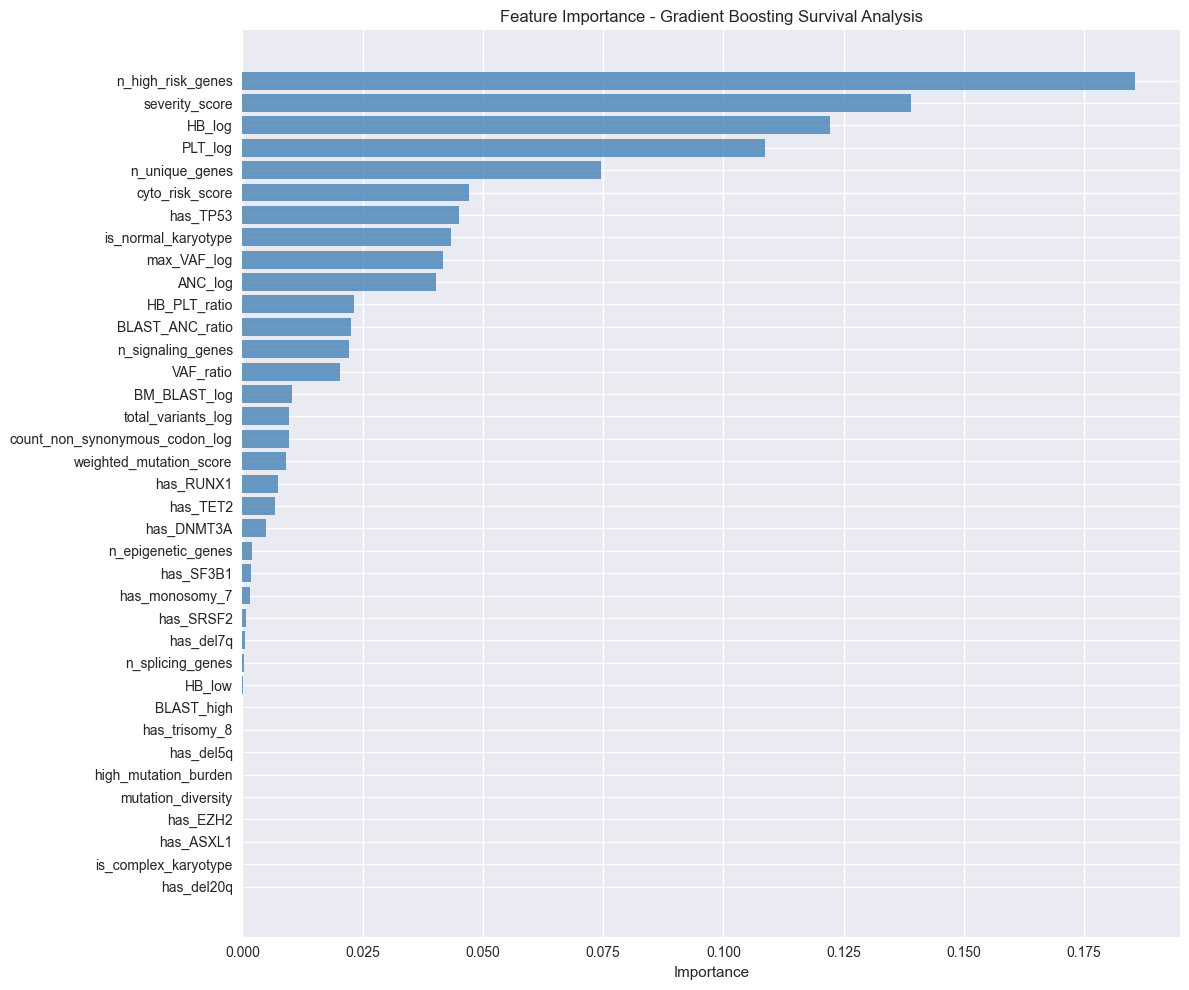


TEST GB AVEC TOP FEATURES PAR IMPORTANCE
Top 10 features: C-index = 0.7124 ± 0.0160
Top 15 features: C-index = 0.7146 ± 0.0166
Top 20 features: C-index = 0.7152 ± 0.0164
Top 25 features: C-index = 0.7156 ± 0.0166
Top 30 features: C-index = 0.7158 ± 0.0169
Top 35 features: C-index = 0.7158 ± 0.0169
Top 37 features: C-index = 0.7158 ± 0.0169

✓ Meilleur nombre de features: 37
✓ C-index CV: 0.7158


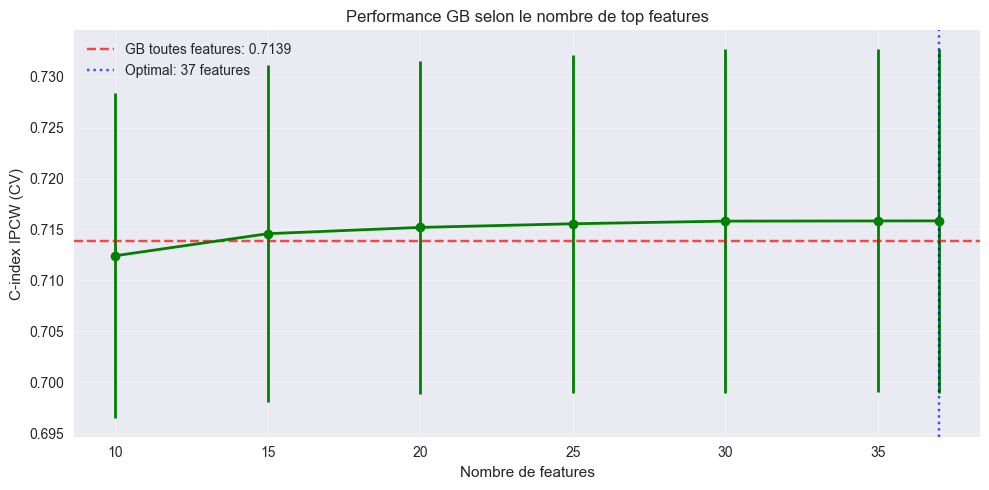


📊 Top 37 features:
    1. n_high_risk_genes: 0.1857
    2. severity_score: 0.1390
    3. HB_log: 0.1222
    4. PLT_log: 0.1087
    5. n_unique_genes: 0.0746
    6. cyto_risk_score: 0.0472
    7. has_TP53: 0.0450
    8. is_normal_karyotype: 0.0433
    9. max_VAF_log: 0.0417
   10. ANC_log: 0.0403
   11. HB_PLT_ratio: 0.0232
   12. BLAST_ANC_ratio: 0.0225
   13. n_signaling_genes: 0.0222
   14. VAF_ratio: 0.0204
   15. BM_BLAST_log: 0.0103
   16. total_variants_log: 0.0097
   17. count_non_synonymous_codon_log: 0.0097
   18. weighted_mutation_score: 0.0090
   19. has_RUNX1: 0.0073
   20. has_TET2: 0.0068
   21. has_DNMT3A: 0.0048
   22. n_epigenetic_genes: 0.0020
   23. has_SF3B1: 0.0017
   24. has_monosomy_7: 0.0015
   25. has_SRSF2: 0.0007
   26. has_del7q: 0.0004
   27. n_splicing_genes: 0.0002
   28. HB_low: 0.0001
   29. BLAST_high: 0.0000
   30. has_trisomy_8: 0.0000
   31. has_del5q: 0.0000
   32. high_mutation_burden: 0.0000
   33. mutation_diversity: 0.0000
   34. has_EZH2: 0.0

In [27]:
# Feature Selection par importance GB - Test différents nombres de features
# =========================================================================

# 1. Entraîner un GB sur toutes les features pour obtenir les importances
train_temp = final_train.copy()
knn_temp = KNNImputer(n_neighbors=5)
train_temp[all_features] = knn_temp.fit_transform(train_temp[all_features])
sc_temp = StandardScaler()
train_temp[all_features] = sc_temp.fit_transform(train_temp[all_features])
train_temp = train_temp.dropna(subset=['OS_YEARS', 'OS_STATUS'])
y_temp = Surv.from_arrays(train_temp['OS_STATUS'].astype(bool), train_temp['OS_YEARS'])

gb_importance = GradientBoostingSurvivalAnalysis(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
gb_importance.fit(train_temp[all_features], y_temp)

# 2. Classement des features par importance
importance_df = pd.DataFrame({
    'feature': all_features, 
    'importance': gb_importance.feature_importances_
}).sort_values('importance', ascending=False)

print("=" * 60)
print("FEATURE IMPORTANCE (Gradient Boosting)")
print("=" * 60)
print(importance_df.to_string(index=False))

# 3. Visualisation
plt.figure(figsize=(12, 10))
plt.barh(range(len(importance_df)), importance_df['importance'].values, color='steelblue', alpha=0.8)
plt.yticks(range(len(importance_df)), importance_df['feature'].values)
plt.xlabel('Importance')
plt.title('Feature Importance - Gradient Boosting Survival Analysis')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# 4. Test avec différents nombres de top features
print("\n" + "=" * 60)
print("TEST GB AVEC TOP FEATURES PAR IMPORTANCE")
print("=" * 60)

results_top_features = []

for n_top in [10, 15, 20, 25, 30, 35, 37]:
    top_features = importance_df.head(n_top)['feature'].tolist()
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores_top = []
    
    for train_idx, val_idx in kf.split(final_train):
        train_fold = final_train.iloc[train_idx].copy()
        val_fold = final_train.iloc[val_idx].copy()
        
        # Imputation
        knn = KNNImputer(n_neighbors=5)
        train_fold[top_features] = knn.fit_transform(train_fold[top_features])
        val_fold[top_features] = knn.transform(val_fold[top_features])
        
        # Standardisation
        sc = StandardScaler()
        train_fold[top_features] = sc.fit_transform(train_fold[top_features])
        val_fold[top_features] = sc.transform(val_fold[top_features])
        
        train_fold = train_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
        val_fold = val_fold.dropna(subset=['OS_YEARS', 'OS_STATUS'])
        
        # Préparation données
        y_tr = Surv.from_arrays(train_fold['OS_STATUS'].astype(bool), train_fold['OS_YEARS'])
        y_val = Surv.from_arrays(val_fold['OS_STATUS'].astype(bool), val_fold['OS_YEARS'])
        
        # Gradient Boosting avec meilleurs hyperparamètres
        gb = GradientBoostingSurvivalAnalysis(
            n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42
        )
        gb.fit(train_fold[top_features], y_tr)
        
        scores = gb.predict(val_fold[top_features])
        c_index = concordance_index_ipcw(y_tr, y_val, scores, tau=7)[0]
        cv_scores_top.append(c_index)
    
    mean_score = np.mean(cv_scores_top)
    std_score = np.std(cv_scores_top)
    results_top_features.append({'n_features': n_top, 'mean': mean_score, 'std': std_score})
    print(f"Top {n_top:2d} features: C-index = {mean_score:.4f} ± {std_score:.4f}")

# 5. Identifier le meilleur nombre de features
results_top_df = pd.DataFrame(results_top_features)
best_n_features = results_top_df.loc[results_top_df['mean'].idxmax(), 'n_features']
best_score_top = results_top_df['mean'].max()

print(f"\n✓ Meilleur nombre de features: {int(best_n_features)}")
print(f"✓ C-index CV: {best_score_top:.4f}")

# 6. Visualisation
plt.figure(figsize=(10, 5))
plt.errorbar(results_top_df['n_features'], results_top_df['mean'], 
             yerr=results_top_df['std'], fmt='o-', capsize=4, color='green', linewidth=2)
plt.axhline(best_score_gb, color='red', linestyle='--', alpha=0.7, label=f'GB toutes features: {best_score_gb:.4f}')
plt.axvline(best_n_features, color='blue', linestyle=':', alpha=0.7, label=f'Optimal: {int(best_n_features)} features')
plt.xlabel('Nombre de features')
plt.ylabel('C-index IPCW (CV)')
plt.title('Performance GB selon le nombre de top features')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Afficher les top features sélectionnées
best_features = importance_df.head(int(best_n_features))['feature'].tolist()
print(f"\n📊 Top {int(best_n_features)} features:")
for i, f in enumerate(best_features, 1):
    imp = importance_df[importance_df['feature'] == f]['importance'].values[0]
    print(f"   {i:2d}. {f}: {imp:.4f}")

In [36]:
# =============================================================================
# SOUMISSION FINALE - Gradient Boosting (meilleur modèle)
# =============================================================================


import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sksurv.ensemble import GradientBoostingSurvivalAnalysis
from sksurv.util import Surv

# --- 1. CHARGEMENT DES DONNÉES ---
clinical_train = pd.read_csv('raw_data/X_train/clinical_train.csv')
clinical_test = pd.read_csv('raw_data/X_test/clinical_test.csv')
molecular_train = pd.read_csv('raw_data/X_train/molecular_train.csv')
molecular_test = pd.read_csv('raw_data/X_test/molecular_test.csv')
target_train = pd.read_csv('raw_data/target_train.csv')

# --- 2. FEATURE ENGINEERING ---
def build_features(clinical_df, molecular_df, is_train=True, median_variants=None):
    """Construit les 37 features pour train ou test"""
    
    # Transformations log cliniques
    clinical_eng = clinical_df.copy()
    for col in ['BM_BLAST', 'ANC', 'HB', 'PLT']:
        clinical_eng[f'{col}_log'] = np.log1p(clinical_df[col])
    
    # Features cliniques avancées
    clinical_eng['severity_score'] = (
        clinical_eng['BM_BLAST_log'] * 2 +
        (1 / (clinical_eng['HB_log'] + 0.1)) +
        (1 / (clinical_eng['PLT_log'] + 0.1))
    )
    clinical_eng['HB_PLT_ratio'] = np.log1p(clinical_df['HB'] / (clinical_df['PLT'] + 1))
    clinical_eng['BLAST_ANC_ratio'] = np.log1p(clinical_df['BM_BLAST'] / (clinical_df['ANC'] + 0.1))
    clinical_eng['HB_low'] = (clinical_df['HB'] < 10).astype(int)
    clinical_eng['BLAST_high'] = (clinical_df['BM_BLAST'] > 20).astype(int)
    
    # Aggregation moléculaire
    molecular_agg = molecular_df.groupby('ID').agg({
        'CHR': 'count', 'VAF': ['mean', 'max']
    }).reset_index()
    molecular_agg.columns = ['ID', 'total_variants', 'mean_VAF', 'max_VAF']
    
    pertinent_effects = ['non_synonymous_codon', 'frameshift_variant', 'splice_site_variant', 'stop_gained']
    effect_counts = molecular_df[molecular_df['EFFECT'].isin(pertinent_effects)].pivot_table(
        index='ID', columns='EFFECT', aggfunc='size', fill_value=0
    )
    effect_counts.columns = [f'count_{col}' for col in effect_counts.columns]
    molecular_agg = molecular_agg.merge(effect_counts, left_on='ID', right_index=True, how='left').fillna(0)
    for effect in pertinent_effects:
        if f'count_{effect}' not in molecular_agg.columns:
            molecular_agg[f'count_{effect}'] = 0
    
    # Transformations log moléculaires
    molecular_eng = molecular_agg.copy()
    for col in ['total_variants', 'max_VAF', 'count_non_synonymous_codon']:
        molecular_eng[f'{col}_log'] = np.log1p(molecular_agg[col])
    
    # Features moléculaires avancées
    molecular_eng['weighted_mutation_score'] = (
        molecular_eng['total_variants_log'] +
        molecular_eng['count_non_synonymous_codon_log'] * 1.5 +
        np.log1p(molecular_agg['count_frameshift_variant']) * 2 +
        np.log1p(molecular_agg['count_stop_gained']) * 2.5
    )
    molecular_eng['VAF_ratio'] = np.log1p(molecular_agg['max_VAF'] / (molecular_agg['mean_VAF'] + 0.01))
    
    if is_train:
        median_variants = molecular_agg['total_variants'].median()
    molecular_eng['high_mutation_burden'] = (molecular_agg['total_variants'] > median_variants).astype(int)
    molecular_eng['mutation_diversity'] = (
        (molecular_agg['count_non_synonymous_codon'] > 0).astype(int) +
        (molecular_agg['count_frameshift_variant'] > 0).astype(int) +
        (molecular_agg['count_splice_site_variant'] > 0).astype(int) +
        (molecular_agg['count_stop_gained'] > 0).astype(int)
    )
    
    # Features cytogénétiques
    cyto = clinical_df['CYTOGENETICS'].fillna('MISSING')
    cyto_features = pd.DataFrame({'ID': clinical_df['ID']})
    cyto_features['is_normal_karyotype'] = cyto.str.match(r'^46,(xx|xy)(\[\d+\])?$', case=False).astype(int)
    cyto_features['has_monosomy_7'] = cyto.str.contains('-7', case=False, na=False).astype(int)
    cyto_features['has_del5q'] = cyto.str.contains(r'del.5', case=False, na=False).astype(int)
    cyto_features['has_del7q'] = cyto.str.contains(r'del.7', case=False, na=False).astype(int)
    cyto_features['has_trisomy_8'] = cyto.str.contains(r'\+8', case=False, na=False).astype(int)
    cyto_features['has_del20q'] = cyto.str.contains(r'del.20', case=False, na=False).astype(int)
    cyto_features['is_complex_karyotype'] = cyto.str.count('/').ge(2).astype(int)
    cyto_features['cyto_risk_score'] = 1
    cyto_features.loc[cyto_features['is_normal_karyotype'] == 1, 'cyto_risk_score'] = 0
    cyto_features.loc[cyto_features['has_del7q'] == 1, 'cyto_risk_score'] = 2
    cyto_features.loc[cyto_features['has_monosomy_7'] == 1, 'cyto_risk_score'] = 3
    cyto_features.loc[cyto_features['is_complex_karyotype'] == 1, 'cyto_risk_score'] = 4
    
    # Features génétiques
    gene_groups = {
        'high_risk': ['TP53', 'ASXL1', 'RUNX1', 'EZH2'],
        'splicing': ['SF3B1', 'SRSF2', 'U2AF1', 'ZRSR2'],
        'epigenetic': ['TET2', 'DNMT3A', 'IDH1', 'IDH2', 'EZH2', 'ASXL1'],
        'signaling': ['NRAS', 'KRAS', 'FLT3', 'CBL', 'NF1']
    }
    key_genes = ['TP53', 'ASXL1', 'RUNX1', 'EZH2', 'SF3B1', 'SRSF2', 'TET2', 'DNMT3A']
    genes_by_patient = molecular_df.groupby('ID')['GENE'].apply(set).reset_index()
    genes_by_patient.columns = ['ID', 'gene_set']
    gene_features = pd.DataFrame({'ID': genes_by_patient['ID']})
    for gene in key_genes:
        gene_features[f'has_{gene}'] = genes_by_patient['gene_set'].apply(lambda x: int(gene in x))
    for group_name, genes in gene_groups.items():
        gene_features[f'n_{group_name}_genes'] = genes_by_patient['gene_set'].apply(lambda x: len(x.intersection(genes)))
    gene_features['n_unique_genes'] = genes_by_patient['gene_set'].apply(len)
    
    # Merge final
    clinical_cols = ['BM_BLAST_log', 'ANC_log', 'HB_log', 'PLT_log', 'severity_score', 
                     'HB_PLT_ratio', 'BLAST_ANC_ratio', 'HB_low', 'BLAST_high']
    molecular_cols = ['total_variants_log', 'max_VAF_log', 'count_non_synonymous_codon_log',
                      'weighted_mutation_score', 'VAF_ratio', 'high_mutation_burden', 'mutation_diversity']
    cyto_cols = ['is_normal_karyotype', 'has_monosomy_7', 'has_del5q', 'has_del7q',
                 'has_trisomy_8', 'has_del20q', 'is_complex_karyotype', 'cyto_risk_score']
    gene_cols = ['has_TP53', 'has_ASXL1', 'has_RUNX1', 'has_EZH2', 'has_SF3B1',
                 'has_SRSF2', 'has_TET2', 'has_DNMT3A', 'n_high_risk_genes', 
                 'n_splicing_genes', 'n_epigenetic_genes', 'n_signaling_genes', 'n_unique_genes']
    
    # Merge: garder TOUS les patients cliniques (how='left' pour moléculaire)
    final_df = clinical_eng[['ID'] + clinical_cols].merge(
        molecular_eng[['ID'] + molecular_cols], on='ID', how='left')
    final_df = final_df.merge(cyto_features[['ID'] + cyto_cols], on='ID', how='left')
    final_df = final_df.merge(gene_features[['ID'] + gene_cols], on='ID', how='left')
    
    # Remplir les NaN moléculaires avec 0 pour les patients sans données moléculaires
    for col in molecular_cols:
        final_df[col] = final_df[col].fillna(0)
    
    all_features = clinical_cols + molecular_cols + cyto_cols + gene_cols
    
    return final_df, all_features, median_variants

# --- 3. PRÉPARATION DES DONNÉES ---
train_df, all_features, median_v = build_features(clinical_train, molecular_train, is_train=True)
train_df = train_df.merge(target_train[['ID', 'OS_YEARS', 'OS_STATUS']], on='ID', how='inner')

# Nettoyage des valeurs manquantes dans la target
train_df = train_df.dropna(subset=['OS_YEARS', 'OS_STATUS'])

test_df, _, _ = build_features(clinical_test, molecular_test, is_train=False, median_variants=median_v)

# --- 4. VALIDATION CROISÉE POUR C-INDEX (sur données brutes, imputation par fold) ---
from sklearn.model_selection import KFold
from sksurv.metrics import concordance_index_ipcw

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for train_idx, val_idx in kf.split(train_df):
    # Split sur données BRUTES (avant imputation)
    tr_fold = train_df.iloc[train_idx].copy()
    val_fold = train_df.iloc[val_idx].copy()
    
    # Imputation sur fold
    knn_cv = KNNImputer(n_neighbors=5)
    tr_fold[all_features] = knn_cv.fit_transform(tr_fold[all_features])
    val_fold[all_features] = knn_cv.transform(val_fold[all_features])
    
    # Standardisation sur fold
    sc_cv = StandardScaler()
    X_tr = sc_cv.fit_transform(tr_fold[all_features])
    X_val = sc_cv.transform(val_fold[all_features])
    
    # Target
    y_tr = Surv.from_arrays(tr_fold['OS_STATUS'].astype(bool), tr_fold['OS_YEARS'])
    y_val = Surv.from_arrays(val_fold['OS_STATUS'].astype(bool), val_fold['OS_YEARS'])
    
    # Modèle
    gb_cv = GradientBoostingSurvivalAnalysis(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
    gb_cv.fit(X_tr, y_tr)
    
    # C-index IPCW
    scores = gb_cv.predict(X_val)
    c_idx = concordance_index_ipcw(y_tr, y_val, scores, tau=7)[0]
    cv_scores.append(c_idx)

cv_mean = np.mean(cv_scores)
cv_std = np.std(cv_scores)
print(f"C-index IPCW (5-fold CV): {cv_mean:.4f} ± {cv_std:.4f}")

# --- 5. PRÉPARATION FINALE POUR SOUMISSION ---
# Imputation sur tout le train
knn = KNNImputer(n_neighbors=5)
train_df[all_features] = knn.fit_transform(train_df[all_features])
test_df[all_features] = knn.transform(test_df[all_features])

# Standardisation
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[all_features])
X_test = scaler.transform(test_df[all_features])

# Target
y_train = Surv.from_arrays(train_df['OS_STATUS'].astype(bool), train_df['OS_YEARS'])

# --- 6. ENTRAÎNEMENT DU MODÈLE FINAL ---
gb_final = GradientBoostingSurvivalAnalysis(
    n_estimators=200, 
    learning_rate=0.05, 
    max_depth=3, 
    random_state=42
)
gb_final.fit(X_train, y_train)

# --- 7. PRÉDICTION ET SOUMISSION ---
risk_scores = gb_final.predict(X_test)

# Transformer en scores positifs (shift + scale)
# Les risk scores GB peuvent être négatifs, on les transforme en rang percentile
from scipy.stats import rankdata
risk_scores_positive = rankdata(risk_scores) / len(risk_scores)

submission = pd.DataFrame({
    'ID': test_df['ID'],
    'risk_score': risk_scores_positive
})
submission.to_csv('output/submission_final.csv', index=False)

# --- 8. RÉSUMÉ ---
print("=" * 60)
print("🏆 SOUMISSION FINALE - GRADIENT BOOSTING")
print("=" * 60)
print(f"✓ Modèle: GradientBoostingSurvivalAnalysis")
print(f"✓ Hyperparamètres: n_estimators=200, lr=0.05, max_depth=3")
print(f"✓ Features: {len(all_features)}")
print(f"✓ C-index CV (5-fold): {cv_mean:.4f} ± {cv_std:.4f}")
print(f"\\n✓ Fichier: output/submission_final.csv")
print(f"✓ Prédictions: {len(submission)}")
print("=" * 60)
submission.head()

C-index IPCW (5-fold CV): 0.7167 ± 0.0097
🏆 SOUMISSION FINALE - GRADIENT BOOSTING
✓ Modèle: GradientBoostingSurvivalAnalysis
✓ Hyperparamètres: n_estimators=200, lr=0.05, max_depth=3
✓ Features: 37
✓ C-index CV (5-fold): 0.7167 ± 0.0097
\n✓ Fichier: output/submission_final.csv
✓ Prédictions: 1193


,ID,risk_score
0,KYW1,0.652976
1,KYW2,0.559933
2,KYW3,0.673931
3,KYW4,0.767812
4,KYW5,0.734283
